## Repeater

### Prerequisites

In [24]:
import uuid
import time
from datetime import datetime, date

import numpy as np
import scipy as sp
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

import matplotlib.pyplot as plt
import seaborn as sns

import torch

from utils import (
    Repeater,
    Generator,
    Evaluator,
    device,
)

### MIMO 5x2

#### Data

In [ ]:
A = np.array([[0, 1, 0, 0, 0],
              [-1, -0.5, 0, 0, 0],
              [0, 0, 0, 1, 0],
              [0, 0, -1, -0.5, 0],
              [0, 0, 0, 0, -1]])

B = np.array([[1, 0, 0, 0, 0],
              [0, 1, 0, 0, 0],
              [0, 0, 1, 0, 0],
              [0, 0, 0, 1, 0],
              [0, 0, 0, 0, 1]])

C = np.array([[1, 0, 0, 0, 0],
              [0, 1, 0, 0, 0]])

D = np.zeros((2, 5))

sys = sp.signal.StateSpace(A, B, C, D)

input_size = np.array(D).shape[1]
output_size = np.array(D).shape[0]

signal_length = 60*24*30
sf = 8
t = np.arange(0, signal_length/sf, 1/sf)

params = {
    "period": len(t),
    "initial_value": 0,
    "setpoint_min": 0,
    "setpoint_max": 1e1,
    "setpoint_step": 1e-1,
    "duration_min": 5e1,
    "duration_max": 2e2,
}

In [ ]:
generator = Generator()

x = []
for i in range(input_size):
    x.append(generator.generate_prbs(**params))
x = np.transpose(x)

_, y, _ = sp.signal.lsim(sys, x, t)

batch_size = 2**5
lag = 2**3

train_dataloader, val_dataloader = generator.generate_dataloaders(x, y, lag, batch_size)

In [ ]:
columns = []
for i in range(input_size + output_size):
    columns.append("sensor_" + generator.generate_key())

input_columns = columns[:input_size]
output_columns = columns[input_size:]

data = np.concatenate((x, y), axis=1)
df = pd.DataFrame(data=data)
df.columns = columns
df.index = pd.to_datetime(pd.date_range(start=date.today(), periods=df.shape[0], freq="min").strftime("%Y-%m-%d %H:%M:%S.%f"))
df.index.name = "date_time"

df.to_csv("./datasets/mimo_5x2_dataset.csv")

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(method="pearson"), annot=True)

In [ ]:
for i in range(x.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(x[:, i], label=input_columns[i])
    plt.legend()
    plt.show()

for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(y[:, i], label=output_columns[i], color="tab:orange")
    plt.legend()
    plt.show()

#### Model

In [ ]:
config = {
    "input_size": input_size + output_size,
    "output_size": output_size,
    "hidden_size": 2**5,
    "num_layers": 2**1,
    "learning_rate": 1e-3,
    "dropout": 0,
    "lag": lag,
    "epochs": 2**5,
}

In [ ]:
repeater = Repeater(**config).to(device)
print(repeater)

#### Train

In [ ]:
%%time
repeater.fit(train_dataloader, val_dataloader)

In [ ]:
repeater.data_min = generator.y_scaler.data_min_.tolist()
repeater.data_max = generator.y_scaler.data_max_.tolist()

model_path = './models/repeater_5x2.pt'
# torch.save(repeater.state_dict(), model_path)
torch.jit.script(repeater).save(model_path)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2))
axs[0].plot(repeater.train_loss)
axs[0].set_title('Training Loss')
axs[1].plot(repeater.val_loss, color='tab:orange')
axs[1].set_title('Validation Loss')

for ax in axs.flat:
    ax.set(xlabel='Epoch', ylabel='')

fig.tight_layout()

#### Test

In [ ]:
for parameter in repeater.parameters():
  parameter.requires_grad = False
repeater.eval()

# repeater = torch.jit.load(model_path)
# repeater.eval()

In [ ]:
# y_test_scaled = repeater.forward(generator.x_test)
y_test_scaled = repeater.test(generator.x_test, (generator.x_val, generator.y_val))
y_test = generator.y_scaler.inverse_transform(y_test_scaled)

In [ ]:
plt.figure(figsize=(12, 2))
plt.plot(repeater.y_tick)

In [ ]:
for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(generator.y_scaler.inverse_transform(generator.y_test)[:, i], label='operation')
    plt.plot(y_test[:, i], label='simulation')
    plt.legend()
    plt.show()

#### Evaluate

In [ ]:
evaluator = Evaluator()

for i in range(output_size):
    metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test)[:, i], y_test[:, i])
    print(metrics_dict)

In [ ]:
evaluator = Evaluator()
metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test), y_test)
metrics_dict

In [ ]:
while True:
    time.sleep(1)
    pass

### Zyfra

#### Data

In [121]:
df = pd.read_csv('./datasets/zyfra/zyfra_dataset.csv', parse_dates=["date"], infer_datetime_format=True).set_index('date').astype(float)
# df.index = pd.to_datetime(df.index)
df.index = pd.to_datetime(pd.date_range(start=df.index[0], periods=df.shape[0], freq="h").strftime("%Y-%m-%d %H:%M:%S.%f"))
df = df.resample("h").interpolate(method="linear", limit_direction="both", axis=0)
df.index.name = "date_time"
df.interpolate(method="linear", limit_direction="both", axis=0)
df.fillna(method='ffill', axis=0, inplace=True)
df = df.applymap(lambda x: -x if x < 0 else x)

print(df.shape)

/tmp/ipykernel_97691/2534856036.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv('./datasets/zyfra/zyfra_dataset.csv', parse_dates=["date"], infer_datetime_format=True).set_index('date').astype(float)


(22716, 86)


/tmp/ipykernel_97691/2534856036.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', axis=0, inplace=True)
/tmp/ipykernel_97691/2534856036.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: -x if x < 0 else x)


In [122]:
# Z-score
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3471 entries, 2016-01-29 19:00:00 to 2018-07-31 14:00:00
Data columns (total 86 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         3471 non-null   float64
 1   final.output.concentrate_pb                         3471 non-null   float64
 2   final.output.concentrate_sol                        3471 non-null   float64
 3   final.output.concentrate_au                         3471 non-null   float64
 4   final.output.recovery                               3471 non-null   float64
 5   final.output.tail_ag                                3471 non-null   float64
 6   final.output.tail_pb                                3471 non-null   float64
 7   final.output.tail_sol                               3471 non-null   float64
 8   final.output.tail_au                      

In [124]:
df.head()

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
date_time,,,,,,,,,,,,,,,,,,,,,
2016-01-29 19:00:00,6.216028,10.491338,7.720797,42.600851,72.878517,11.702119,1.205711,8.275870,2.476420,85.938251,...,13.623560,499.432242,13.083908,499.298491,14.036949,499.790065,12.628562,500.206739,14.694700,499.911762
2016-01-29 20:00:00,7.439060,9.674481,7.721502,40.859356,65.944912,12.271132,1.405582,4.790456,2.804975,61.813362,...,12.992534,498.622660,13.047256,497.090905,13.966294,497.920660,11.949566,499.477679,14.050020,498.618889
2016-01-30 14:00:00,5.958196,11.547179,7.215985,41.843601,76.435094,11.097235,1.074875,17.229048,2.374459,172.439903,...,15.006878,499.804568,12.959546,499.588686,13.997204,500.910019,14.003609,500.775497,15.996370,498.981722
2016-02-03 21:00:00,6.124834,9.189736,2.234204,43.667700,64.086801,12.079331,2.262333,11.399560,3.065930,150.002714,...,17.014247,504.222281,15.994992,497.165656,17.890720,498.594870,15.966759,500.106441,17.944239,499.794634
2016-02-04 01:00:00,6.200552,7.895123,2.630558,45.194430,52.963336,11.447746,2.195933,13.481369,3.444854,117.267682,...,16.994768,502.415746,16.025870,504.411666,17.947490,501.406673,16.020308,500.577946,18.018740,500.058834


In [ ]:
# feed_rate (t/h)
# feed_size (um)
# feed_au (%)
# concentrate (%)
# air (Nm³/h)
# level (m)
# reagents (g/t)

columns = [
    # 'final.output.concentrate_ag',
    # 'final.output.concentrate_pb',
    # 'final.output.concentrate_sol',
    # 'final.output.concentrate_au',
    # 'final.output.recovery',
    # 'final.output.tail_ag',
    # 'final.output.tail_pb',
    # 'final.output.tail_sol',
    # 'final.output.tail_au',
    # 'primary_cleaner.input.sulfate',
    # 'primary_cleaner.input.depressant',
    # 'primary_cleaner.input.feed_size',
    # 'primary_cleaner.input.xanthate',
    # 'primary_cleaner.output.concentrate_ag',
    # 'primary_cleaner.output.concentrate_pb',
    # 'primary_cleaner.output.concentrate_sol',
    # 'primary_cleaner.output.concentrate_au',
    # 'primary_cleaner.output.tail_ag',
    # 'primary_cleaner.output.tail_pb',
    # 'primary_cleaner.output.tail_sol',
    # 'primary_cleaner.output.tail_au',
    # 'primary_cleaner.state.floatbank8_a_air',
    # 'primary_cleaner.state.floatbank8_a_level',
    # 'primary_cleaner.state.floatbank8_b_air',
    # 'primary_cleaner.state.floatbank8_b_level',
    # 'primary_cleaner.state.floatbank8_c_air',
    # 'primary_cleaner.state.floatbank8_c_level',
    # 'primary_cleaner.state.floatbank8_d_air',
    # 'primary_cleaner.state.floatbank8_d_level',
    # 'rougher.calculation.sulfate_to_au_concentrate',
    # 'rougher.calculation.floatbank10_sulfate_to_au_feed',
    # 'rougher.calculation.floatbank11_sulfate_to_au_feed',
    # 'rougher.calculation.au_pb_ratio',
    'rougher.input.feed_ag',
    'rougher.input.feed_pb',
    'rougher.input.feed_rate',
    'rougher.input.feed_size',
    'rougher.input.feed_sol',
    'rougher.input.feed_au',
    'rougher.input.floatbank10_sulfate',
    'rougher.input.floatbank10_xanthate',
    # 'rougher.input.floatbank11_sulfate',
    # 'rougher.input.floatbank11_xanthate',
    'rougher.output.concentrate_ag',
    'rougher.output.concentrate_pb',
    'rougher.output.concentrate_sol',
    'rougher.output.concentrate_au',
    # 'rougher.output.recovery',
    'rougher.output.tail_ag',
    'rougher.output.tail_pb',
    'rougher.output.tail_sol',
    'rougher.output.tail_au',
    'rougher.state.floatbank10_a_air',
    'rougher.state.floatbank10_a_level',
    'rougher.state.floatbank10_b_air',
    'rougher.state.floatbank10_b_level',
    # 'rougher.state.floatbank10_c_air',
    # 'rougher.state.floatbank10_c_level',
    # 'rougher.state.floatbank10_d_air',
    # 'rougher.state.floatbank10_d_level',
    'rougher.state.floatbank10_e_air',
    # 'rougher.state.floatbank10_e_level',
    # 'rougher.state.floatbank10_f_air',
    # 'rougher.state.floatbank10_f_level',
    # 'secondary_cleaner.output.tail_ag',
    # 'secondary_cleaner.output.tail_pb',
    # 'secondary_cleaner.output.tail_sol',
    # 'secondary_cleaner.output.tail_au',
    # 'secondary_cleaner.state.floatbank2_a_air',
    # 'secondary_cleaner.state.floatbank2_a_level',
    # 'secondary_cleaner.state.floatbank2_b_air',
    # 'secondary_cleaner.state.floatbank2_b_level',
    # 'secondary_cleaner.state.floatbank3_a_air',
    # 'secondary_cleaner.state.floatbank3_a_level',
    # 'secondary_cleaner.state.floatbank3_b_air',
    # 'secondary_cleaner.state.floatbank3_b_level',
    # 'secondary_cleaner.state.floatbank4_a_air',
    # 'secondary_cleaner.state.floatbank4_a_level',
    # 'secondary_cleaner.state.floatbank4_b_air',
    # 'secondary_cleaner.state.floatbank4_b_level',
    # 'secondary_cleaner.state.floatbank5_a_air',
    # 'secondary_cleaner.state.floatbank5_a_level',
    # 'secondary_cleaner.state.floatbank5_b_air',
    # 'secondary_cleaner.state.floatbank5_b_level',
    # 'secondary_cleaner.state.floatbank6_a_air',
    # 'secondary_cleaner.state.floatbank6_a_level'
 ]

input_columns = [
    # 'rougher.input.feed_ag',
    # 'rougher.input.feed_pb',
    'rougher.input.feed_rate',
    'rougher.input.feed_size',
    # 'rougher.input.feed_sol',
    'rougher.input.feed_au',
    'rougher.input.floatbank10_sulfate',
    'rougher.input.floatbank10_xanthate',
    # 'rougher.input.floatbank11_sulfate',
    # 'rougher.input.floatbank11_xanthate',
    'rougher.state.floatbank10_a_air',
    'rougher.state.floatbank10_a_level',
    # 'rougher.state.floatbank10_b_air',
    # 'rougher.state.floatbank10_b_level',
    # 'rougher.state.floatbank10_c_air',
    # 'rougher.state.floatbank10_c_level',
    # 'rougher.state.floatbank10_d_air',
    # 'rougher.state.floatbank10_d_level',
    # 'rougher.state.floatbank10_e_air',
    # 'rougher.state.floatbank10_e_level',
    # 'rougher.state.floatbank10_f_air',
    # 'rougher.state.floatbank10_f_level',
]

output_columns = [
    # 'rougher.output.concentrate_ag',
    # 'rougher.output.concentrate_pb',
    # 'rougher.output.concentrate_sol',
    'rougher.output.concentrate_au',
    # 'rougher.output.tail_ag',
    # 'rougher.output.tail_pb',
    # 'rougher.output.tail_sol',
    'rougher.output.tail_au',
]

threshold = 0.1
selector = VarianceThreshold(threshold=threshold)
df_selected = pd.DataFrame(selector.fit_transform(df[input_columns]), columns=df[input_columns].columns[selector.get_support()])
input_columns = list(df_selected.columns.values)

df = df[columns]
df[input_columns + output_columns].to_csv("./datasets/zyfra/zyfra_flotation.csv")

<Axes: >

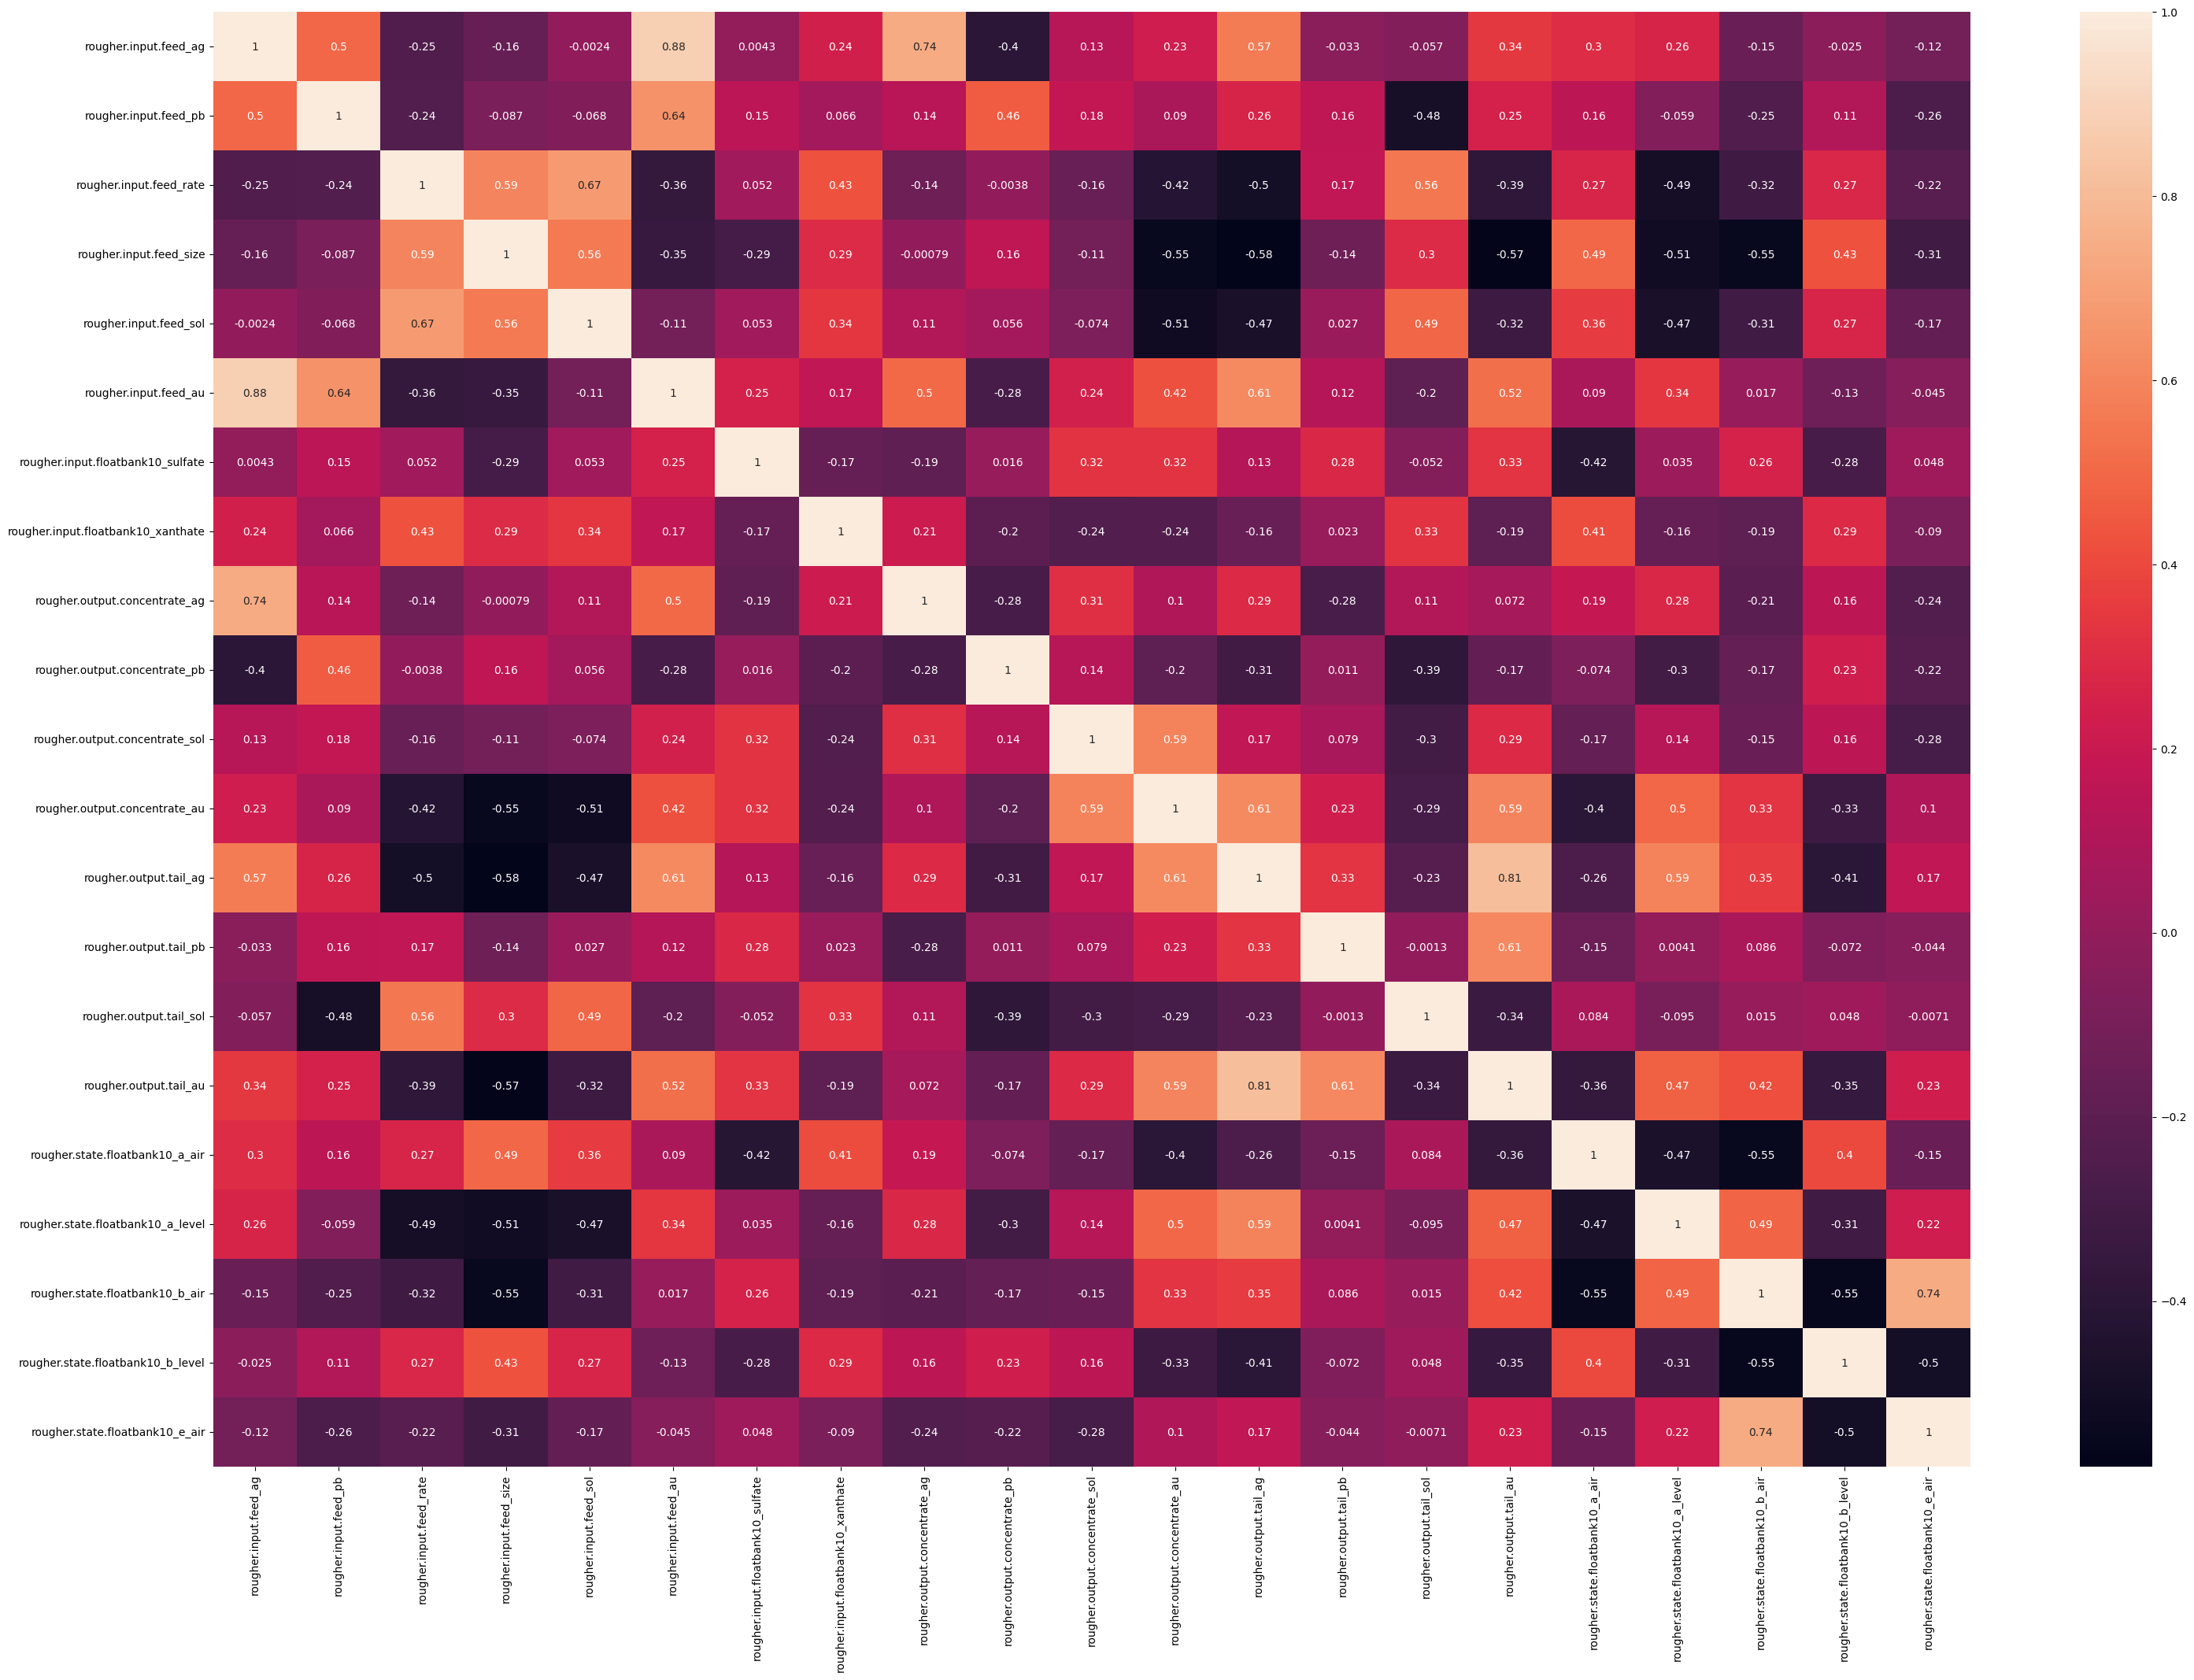

In [126]:
df_corr = df.corr(method="pearson")

plt.figure(figsize=(36, 24))
sns.heatmap(df_corr, annot=True)

In [127]:
# df_corr[output_columns][df_corr[output_columns].abs() >= 0.2]
df_corr[input_columns][df_corr[input_columns] >= 0.8]

,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level
rougher.input.feed_ag,NaN,NaN,0.876884,NaN,NaN,NaN,NaN
rougher.input.feed_pb,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rougher.input.feed_rate,1.0,NaN,NaN,NaN,NaN,NaN,NaN
rougher.input.feed_size,NaN,1.0,NaN,NaN,NaN,NaN,NaN
rougher.input.feed_sol,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rougher.input.feed_au,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
rougher.input.floatbank10_sulfate,NaN,NaN,NaN,1.0,NaN,NaN,NaN
rougher.input.floatbank10_xanthate,NaN,NaN,NaN,NaN,1.0,NaN,NaN
rougher.output.concentrate_ag,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rougher.output.concentrate_pb,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [128]:
input_size = len(input_columns)
output_size = len(output_columns)

x = df[input_columns].values
y = df[output_columns].values

In [129]:
df[input_columns + output_columns].describe()

,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.output.concentrate_au,rougher.output.tail_au
count,3471.000000,3471.000000,3471.000000,3471.000000,3471.000000,3471.000000,3471.000000,3471.000000,3471.000000
mean,503.011965,57.810751,8.343269,12.239093,6.378400,1112.257590,358.871310,20.183798,1.682474
std,75.358772,13.317967,1.858852,2.907692,0.813650,165.964668,86.989593,2.175285,0.635347
min,175.365999,21.345670,3.168345,3.263654,3.260339,685.945050,293.920129,12.599414,0.200281
25%,450.561517,46.696826,6.865532,10.001154,5.992098,999.529965,299.949960,18.907332,1.208950
50%,510.242866,54.844849,8.258610,12.000040,6.402163,1001.266298,300.151319,20.293753,1.732911
75%,558.177783,67.925769,9.849150,14.732392,6.936372,1202.895579,499.525443,21.493483,2.115304
max,697.914084,90.420232,12.803823,20.005140,8.919601,1411.527154,504.408914,26.695481,3.477390


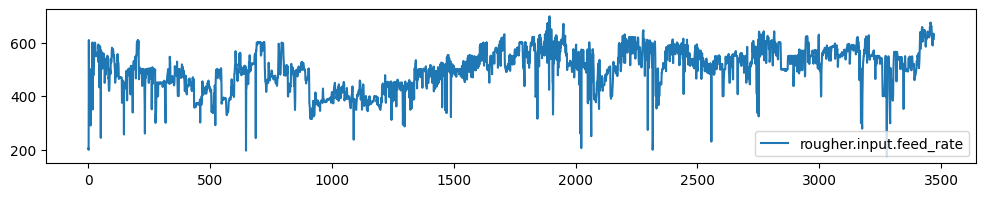

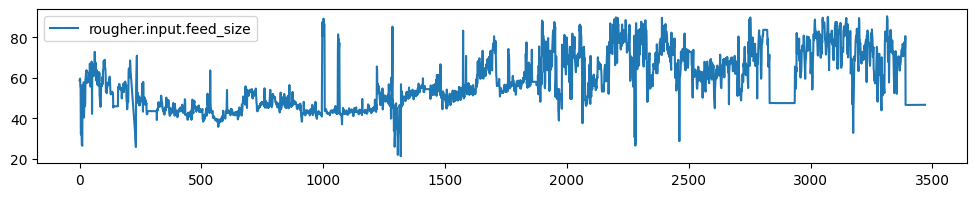

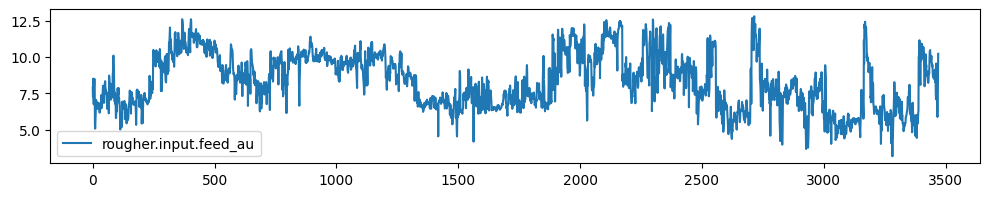

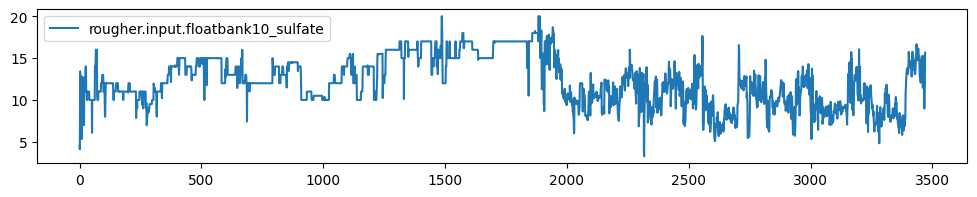

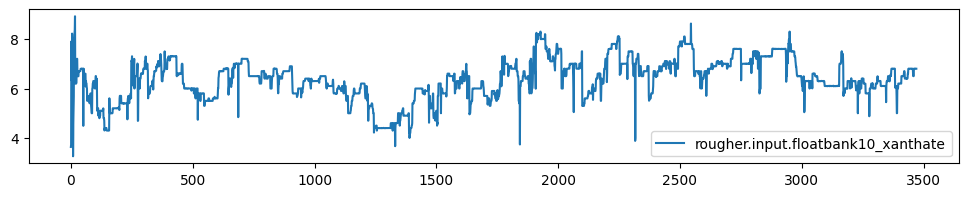

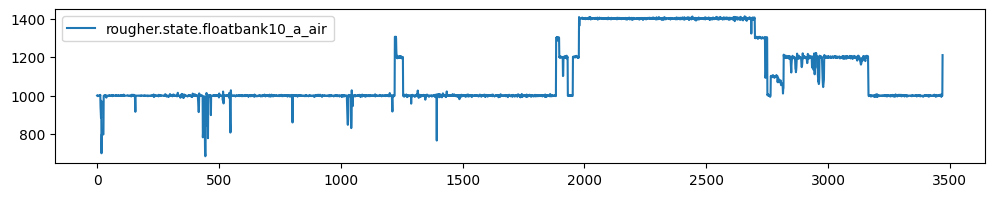

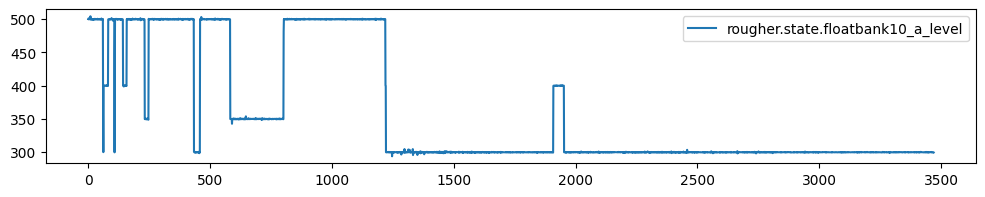

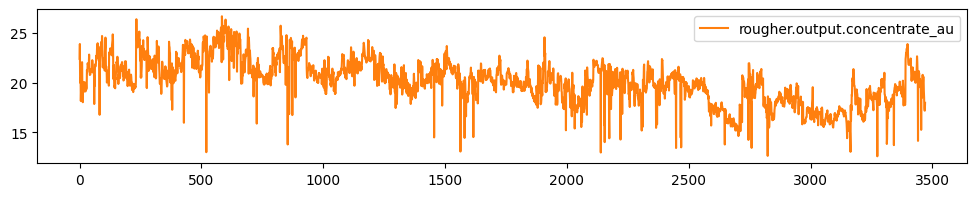

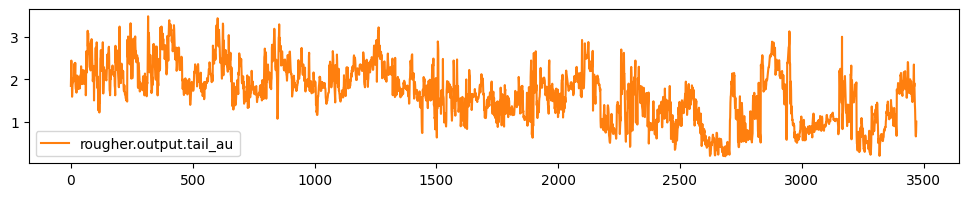

In [130]:
for i in range(x.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(x[:, i], label=input_columns[i])
    plt.legend()
    plt.show()

for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(y[:, i], label=output_columns[i], color="tab:orange")
    plt.legend()
    plt.show()

In [131]:
batch_size = 2**5
lag = 2**5

generator = Generator()
train_dataloader, val_dataloader = generator.generate_dataloaders(x, y, lag, batch_size)

#### Model

In [132]:
config = {
    "input_size": input_size + output_size,
    "output_size": output_size,
    "hidden_size": 2**3,
    "num_layers": 2**1,
    "learning_rate": 1e-3,
    "dropout": 0,
    "lag": lag,
    "epochs": 2**7
}

In [133]:
repeater = Repeater(**config).to(device)
print(repeater)

Repeater(
  (lstm): LSTM(9, 8, num_layers=2, batch_first=True)
  (linear): Linear(in_features=8, out_features=2, bias=True)
  (loss_fn): MSELoss()
)


#### Train

In [134]:
%%time
repeater.fit(train_dataloader, val_dataloader)

Epoch 1/128
54/54 [====================================================================================================] 100%
0.0017s 0.0017s/step - train_loss: 0.06729376 - val_loss: 0.14992412 

Epoch 2/128
54/54 [====================================================================================================] 100%
0.0031s 0.0016s/step - train_loss: 0.06082277 - val_loss: 0.12055884 

Epoch 3/128
54/54 [====================================================================================================] 100%
0.0045s 0.0015s/step - train_loss: 0.05401965 - val_loss: 0.10976105 

Epoch 4/128
54/54 [====================================================================================================] 100%
0.0059s 0.0015s/step - train_loss: 0.04973600 - val_loss: 0.10141143 

Epoch 5/128
54/54 [====================================================================================================] 100%
0.0074s 0.0015s/step - train_loss: 0.04668982 - val_loss: 0.09578956 

Epoch 6/128
54/

In [135]:
repeater.x_min_ = generator.x_scaler.min_.tolist()
repeater.x_scale_ = generator.x_scaler.scale_.tolist()
repeater.x_data_min_ = generator.x_scaler.data_min_.tolist()
repeater.x_data_max_ = generator.x_scaler.data_max_.tolist()
repeater.x_data_range_ = generator.x_scaler.data_range_.tolist()
repeater.x_n_features_in_ = generator.x_scaler.n_features_in_
repeater.x_n_samples_seen_ = generator.x_scaler.n_samples_seen_

repeater.y_min_ = generator.y_scaler.min_.tolist()
repeater.y_scale_ = generator.y_scaler.scale_.tolist()
repeater.y_data_min_ = generator.y_scaler.data_min_.tolist()
repeater.y_data_max_ = generator.y_scaler.data_max_.tolist()
repeater.y_data_range_ = generator.y_scaler.data_range_.tolist()
repeater.y_n_features_in_ = generator.y_scaler.n_features_in_
repeater.y_n_samples_seen_ = generator.y_scaler.n_samples_seen_

model_path = "./models/{}.pt".format(uuid.uuid4())
torch.jit.script(repeater).save(model_path)

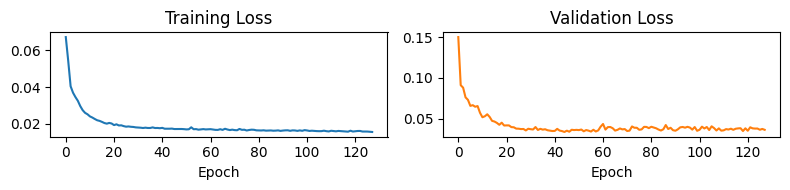

In [136]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2))
axs[0].plot(repeater.train_loss)
axs[0].set_title('Training Loss')
axs[1].plot(repeater.val_loss, color='tab:orange')
axs[1].set_title('Validation Loss')

for ax in axs.flat:
    ax.set(xlabel='Epoch', ylabel='')

fig.tight_layout()

#### Test

In [137]:
for parameter in repeater.parameters():
  parameter.requires_grad = False
repeater.eval()

Repeater(
  (lstm): LSTM(9, 8, num_layers=2, batch_first=True)
  (linear): Linear(in_features=8, out_features=2, bias=True)
  (loss_fn): MSELoss()
)

In [138]:
# y_test_scaled = repeater.test(generator.x_test, (generator.x_val, generator.y_val))
y_test_scaled = repeater.test(generator.x_test)
y_test = generator.y_scaler.inverse_transform(y_test_scaled)

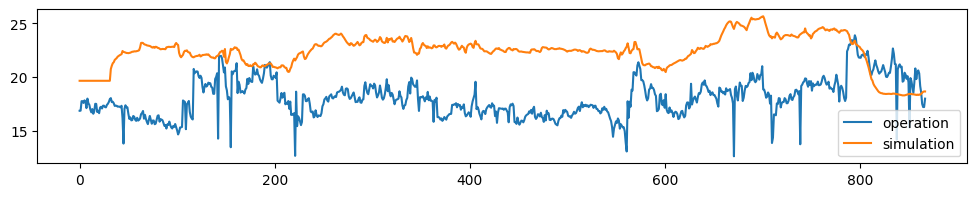

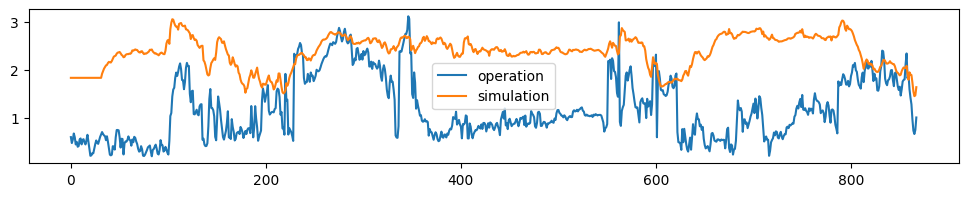

In [139]:
for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(generator.y_scaler.inverse_transform(generator.y_test)[:, i], label='operation')
    plt.plot(y_test[:, i], label='simulation')
    plt.legend()
    plt.show()


#### Evaluate

In [140]:
evaluator = Evaluator()

for i in range(output_size):
    metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test)[:, i], y_test[:, i])
    print(metrics_dict)

{'explained_variance_score': -0.929398385567825, 'mean_absolute_error': 4.583704246180949, 'mean_squared_error': 24.86250171944695, 'root_mean_squared_error': np.float64(4.986231213997898), 'median_absolute_error': 5.079000274838732, 'mean_absolute_percentage_error': 0.26495967515463476, 'd2_absolute_error_score': -2.2858552325774344, 'd2_pinball_score': -2.2858552325774344, 'r2_score': -7.064231396882247}
{'explained_variance_score': -0.05018825810227745, 'mean_absolute_error': 1.1987342524239828, 'mean_squared_error': 1.841444591427177, 'root_mean_squared_error': np.float64(1.356998375617), 'median_absolute_error': 1.3593348446905418, 'mean_absolute_percentage_error': 1.7458621378664787, 'd2_absolute_error_score': -1.3195907478079287, 'd2_pinball_score': -1.3195907478079287, 'r2_score': -3.4487780881836363}


In [141]:
evaluator = Evaluator()
metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test), y_test)
metrics_dict

{'explained_variance_score': -0.48979332183504987,
 'mean_absolute_error': 2.8912192493024667,
 'mean_squared_error': 13.351973155437069,
 'root_mean_squared_error': np.float64(3.654035188040349),
 'median_absolute_error': 3.219167559764637,
 'mean_absolute_percentage_error': 1.0054109065105568,
 'd2_absolute_error_score': -1.8027229901926842,
 'd2_pinball_score': -1.8027229901926842,
 'r2_score': -5.25650474253294}

In [ ]:
while True:
    time.sleep(1)
    pass

### Iron Flotation

#### Data

In [ ]:
df = pd.read_csv('./datasets/iron/iron_flotation.csv', decimal=',', parse_dates=["date"], infer_datetime_format=True).set_index('date').astype(float)
df.index = pd.to_datetime(pd.date_range(start=df.index[0], periods=df.shape[0], freq="20s").strftime("%Y-%m-%d %H:%M:%S.%f"))
df = df.resample("20s").interpolate(method="linear", limit_direction="both", axis=0)
df.index.name = "date_time"
df.interpolate(method="linear", limit_direction="both", axis=0)
df.fillna(method='ffill', axis=0, inplace=True)

df = df.iloc[450000:500000, :]

/tmp/ipykernel_97691/2460477616.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv('./datasets/iron/iron_flotation.csv', decimal=',', parse_dates=["date"], infer_datetime_format=True).set_index('date').astype(float)
/tmp/ipykernel_97691/2460477616.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', axis=0, inplace=True)


In [ ]:
# Z-score
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 23093 entries, 2017-06-22 05:50:20 to 2017-07-03 16:27:20
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   % Iron Feed                   23093 non-null  float64
 1   % Silica Feed                 23093 non-null  float64
 2   Starch Flow                   23093 non-null  float64
 3   Amina Flow                    23093 non-null  float64
 4   Ore Pulp Flow                 23093 non-null  float64
 5   Ore Pulp pH                   23093 non-null  float64
 6   Ore Pulp Density              23093 non-null  float64
 7   Flotation Column 01 Air Flow  23093 non-null  float64
 8   Flotation Column 02 Air Flow  23093 non-null  float64
 9   Flotation Column 03 Air Flow  23093 non-null  float64
 10  Flotation Column 04 Air Flow  23093 non-null  float64
 11  Flotation Column 05 Air Flow  23093 non-null  float64
 12  Flotation Column 06 Air F

In [ ]:
df.head()

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date_time,,,,,,,,,,,,,,,,,,,,,
2017-06-22 05:50:20,50.7,22.76,2259.18,456.726973,394.662233,10.4718,1.709992,299.428,298.205,297.316,...,309.862,398.389,581.215000,537.685,582.833,432.628,394.554,399.006,66.13,1.28
2017-06-22 05:50:40,50.7,22.76,2407.68,451.154459,395.166977,10.4741,1.706240,297.366,298.123,298.516,...,307.495,394.468,581.138000,629.101,596.012,494.198,409.571,408.086,66.13,1.28
2017-06-22 05:51:00,50.7,22.76,2326.17,445.581946,395.671721,10.4763,1.702487,296.631,299.487,301.245,...,300.146,390.881,563.008000,680.913,615.234,497.355,407.163,409.404,66.13,1.28
2017-06-22 08:45:40,50.7,22.76,3111.29,523.561000,399.043000,10.0045,1.625310,297.049,293.576,300.359,...,307.546,395.732,515.609000,468.614,372.186,424.562,396.941,350.471,64.38,2.62
2017-06-22 08:46:40,50.7,22.76,2989.81,521.397000,399.174000,10.0016,1.624480,303.182,299.874,299.292,...,296.060,366.715,308.960667,388.066,419.438,389.706,412.393,394.780,64.38,2.62


In [ ]:
columns = [
    "% Iron Feed",
    "% Silica Feed",
    "Starch Flow",
    "Amina Flow",
    "Ore Pulp Flow",
    "Ore Pulp pH",
    "Ore Pulp Density",    
    "Flotation Column 01 Air Flow",
    "Flotation Column 02 Air Flow",
    "Flotation Column 03 Air Flow",
    "Flotation Column 04 Air Flow",
    "Flotation Column 05 Air Flow",
    "Flotation Column 06 Air Flow",
    "Flotation Column 07 Air Flow",
    "Flotation Column 01 Level",
    "Flotation Column 02 Level",
    "Flotation Column 03 Level",
    "Flotation Column 04 Level",
    "Flotation Column 05 Level",
    "Flotation Column 06 Level",
    "Flotation Column 07 Level", 
    "% Iron Concentrate",
    "% Silica Concentrate",
]

input_columns = [
    "% Iron Feed",
    "% Silica Feed",
    "Starch Flow",
    "Amina Flow",
    "Ore Pulp Flow",
    "Ore Pulp pH",
    "Ore Pulp Density",    
    "Flotation Column 01 Air Flow",
    # "Flotation Column 02 Air Flow",
    # "Flotation Column 03 Air Flow",
    "Flotation Column 04 Air Flow",
    "Flotation Column 05 Air Flow",
    "Flotation Column 06 Air Flow",
    "Flotation Column 07 Air Flow",
    "Flotation Column 01 Level",
    "Flotation Column 02 Level",
    # "Flotation Column 03 Level",
    "Flotation Column 04 Level",
    "Flotation Column 05 Level",
    "Flotation Column 06 Level",
    "Flotation Column 07 Level", 
]

input_columns = [
    "% Iron Feed",
    "% Silica Feed",
    "Starch Flow",
    "Amina Flow",
    "Ore Pulp Flow",
    "Ore Pulp pH",
    "Ore Pulp Density",    
    # "Flotation Column 01 Air Flow",
    # "Flotation Column 02 Air Flow",
    # "Flotation Column 03 Air Flow",
    # "Flotation Column 04 Air Flow",
    "Flotation Column 05 Air Flow",
    # "Flotation Column 06 Air Flow",
    # "Flotation Column 07 Air Flow",
    "Flotation Column 01 Level",
    # "Flotation Column 02 Level",
    # "Flotation Column 03 Level",
    # "Flotation Column 04 Level",
    # "Flotation Column 05 Level",
    # "Flotation Column 06 Level",
    # "Flotation Column 07 Level", 
]

output_columns = [
    "% Iron Concentrate",
    "% Silica Concentrate",
]

# threshold = 0.1
# selector = VarianceThreshold(threshold=threshold)
# df_selected = pd.DataFrame(selector.fit_transform(df[input_columns]), columns=df[input_columns].columns[selector.get_support()])
# input_columns = list(df_selected.columns.values)


df.index.names = ["date_time"]
df = df[columns]

<Axes: >

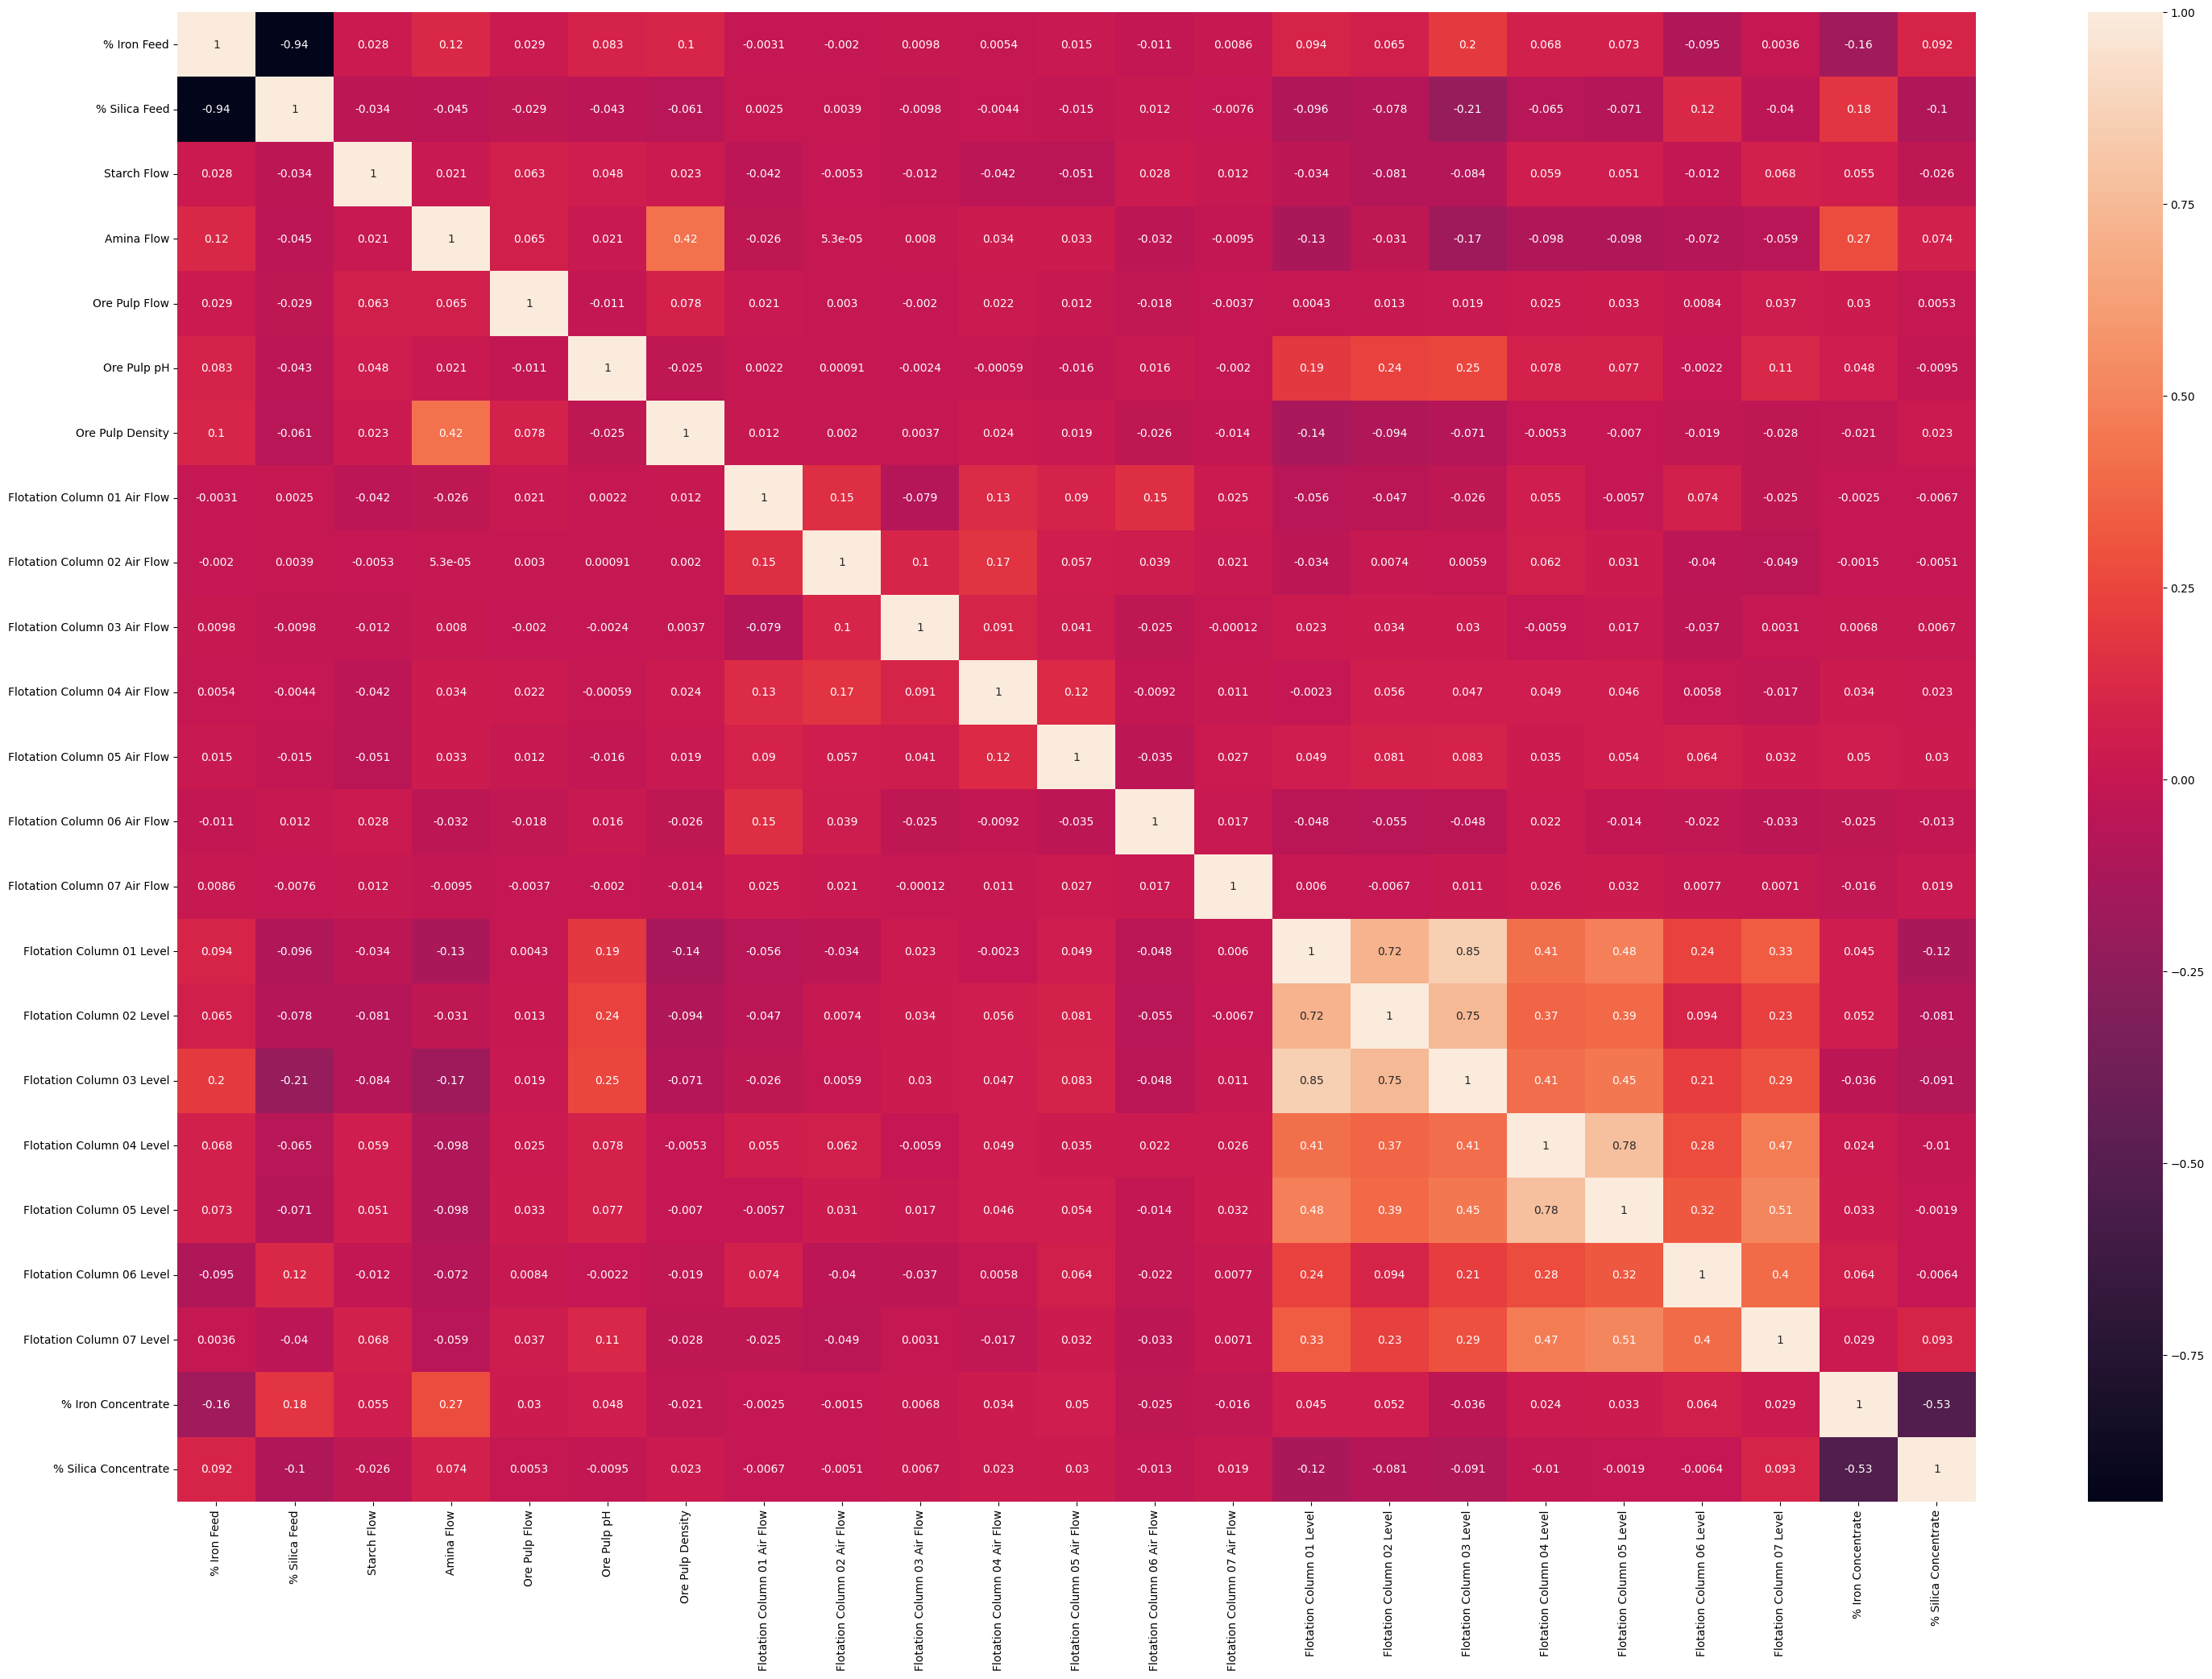

In [ ]:
df_corr = df.corr(method="pearson")

plt.figure(figsize=(36, 24))
sns.heatmap(df_corr, annot=True)

In [ ]:
df_corr[input_columns][df_corr[input_columns] >= 0.8]

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 05 Air Flow,Flotation Column 01 Level
% Iron Feed,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
% Silica Feed,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Starch Flow,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
Amina Flow,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
Ore Pulp Flow,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
Ore Pulp pH,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
Ore Pulp Density,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
Flotation Column 01 Air Flow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flotation Column 02 Air Flow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flotation Column 03 Air Flow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
input_size = len(input_columns)
output_size = len(output_columns)

x = df[input_columns].values
y = df[output_columns].values

In [ ]:
df[input_columns + output_columns].describe()

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 05 Air Flow,Flotation Column 01 Level,% Iron Concentrate,% Silica Concentrate
count,23093.000000,23093.000000,23093.000000,23093.000000,23093.000000,23093.000000,23093.000000,23093.000000,23093.000000,23093.000000,23093.000000
mean,52.813491,18.631023,3535.301527,491.370329,400.151676,10.088301,1.701187,300.032099,530.165503,65.657589,1.489598
std,2.884505,4.782203,830.287376,58.840351,4.298747,0.240789,0.033935,2.226856,59.497299,0.675312,0.452804
min,46.190000,8.100000,998.783769,268.374500,387.322000,9.404690,1.583560,293.117000,303.851500,63.590000,0.960000
25%,50.800000,15.740000,3027.960000,446.637000,397.220000,9.937360,1.685260,298.349000,495.332000,65.240000,1.180000
50%,53.630000,16.860000,3533.810000,490.734000,400.267000,10.087200,1.707040,299.927000,509.033000,65.710000,1.370000
75%,55.210000,21.930000,4107.790000,534.668000,402.888000,10.253800,1.724780,301.690000,585.481000,66.200000,1.640000
max,59.380000,30.370000,5948.410000,711.994000,412.690061,10.766200,1.783450,306.351000,774.598220,66.800000,3.328504


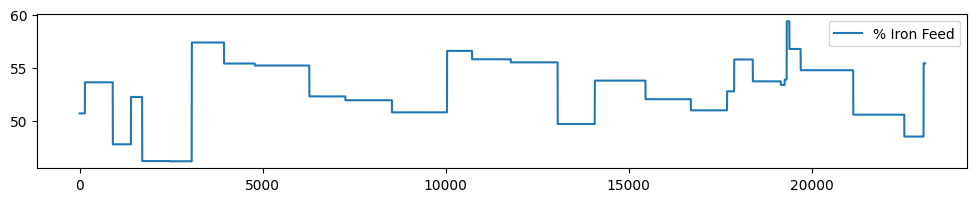

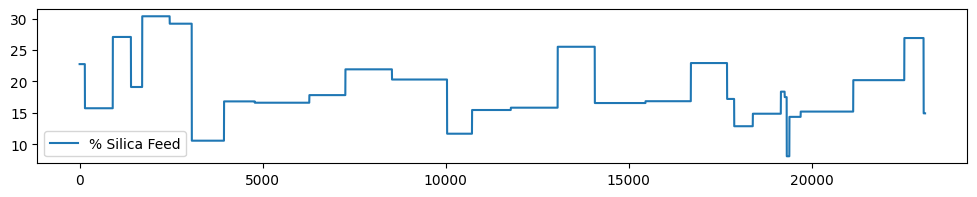

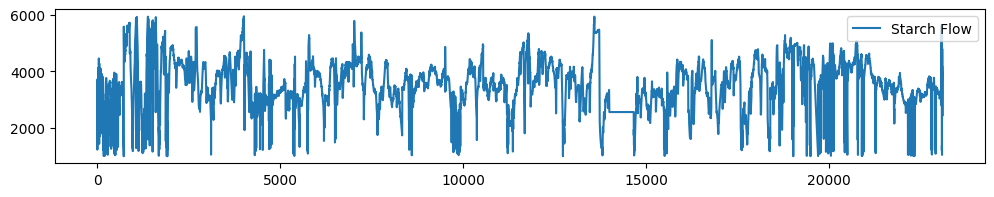

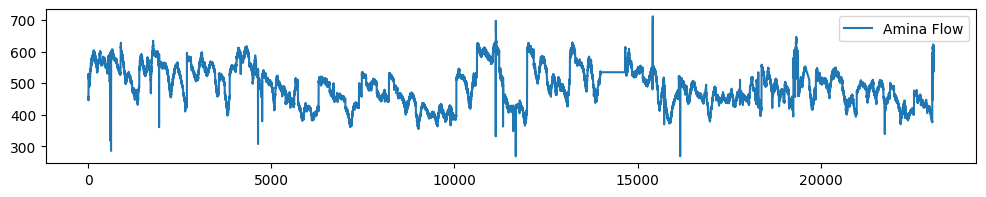

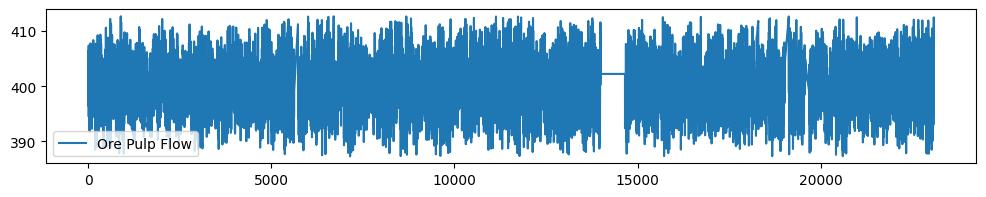

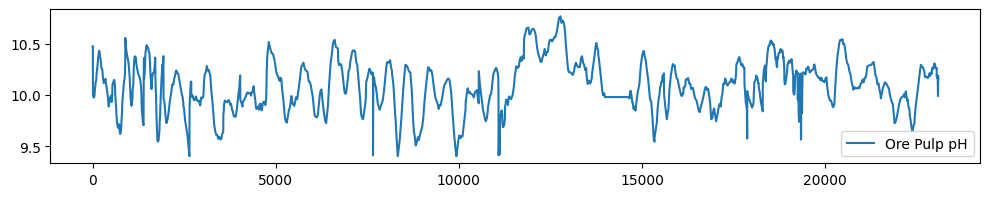

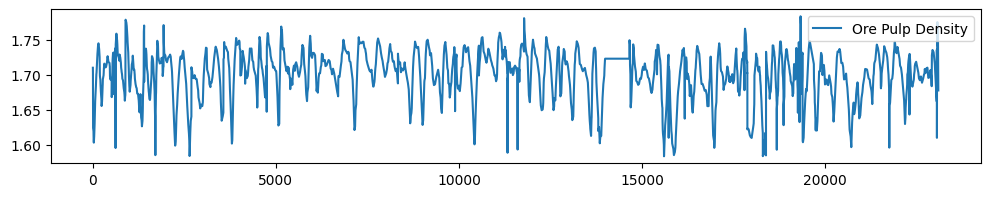

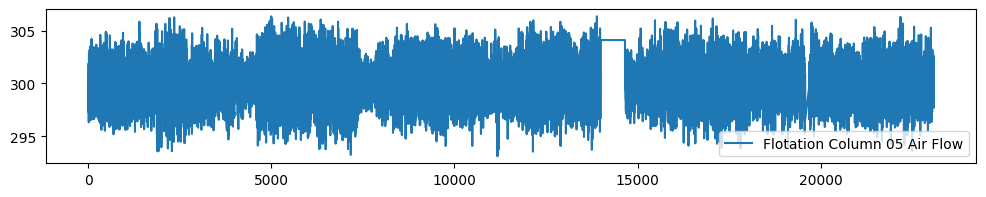

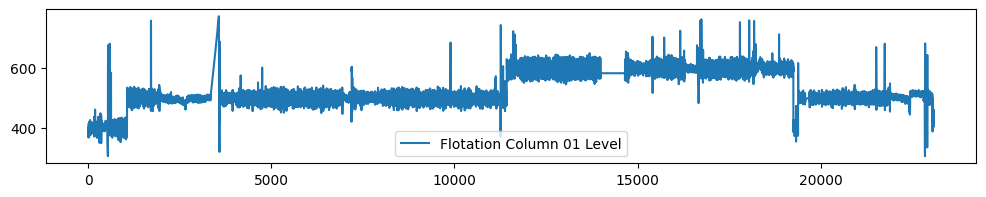

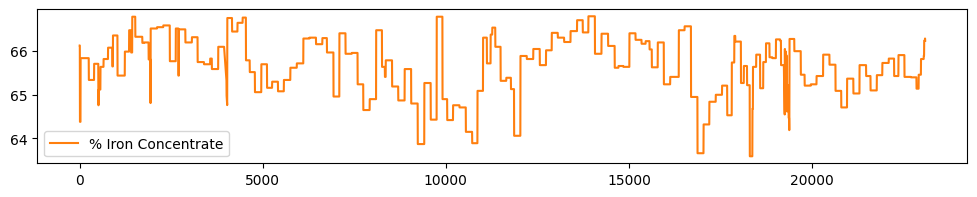

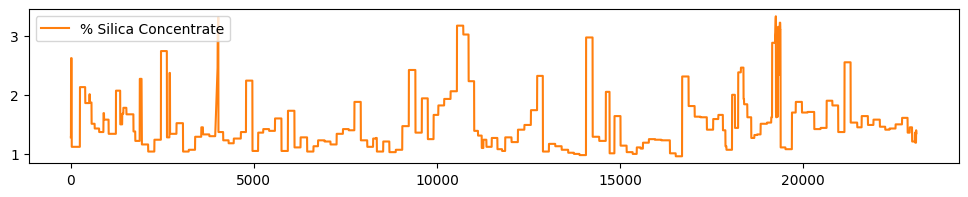

In [ ]:
for i in range(x.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(x[:, i], label=input_columns[i])
    plt.legend()
    plt.show()

for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(y[:, i], label=output_columns[i], color="tab:orange")
    plt.legend()
    plt.show()

In [ ]:
batch_size = 2**5
lag = 2**5

generator = Generator()
train_dataloader, val_dataloader = generator.generate_dataloaders(x, y, lag, batch_size)

#### Model

In [ ]:
config = {
    "input_size": input_size + output_size,
    "output_size": output_size,
    "hidden_size": 2**3,
    "num_layers": 2**1,
    "learning_rate": 1e-3,
    "dropout": 0,
    "lag": lag,
    "epochs": 2**7
}

In [ ]:
repeater = Repeater(**config).to(device)
print(repeater)

Repeater(
  (lstm): LSTM(11, 8, num_layers=2, batch_first=True)
  (linear): Linear(in_features=8, out_features=2, bias=True)
  (loss_fn): MSELoss()
)


#### Train

In [ ]:
%%time
repeater.fit(train_dataloader, val_dataloader)

Epoch 1/128
360/360 [====================================================================================================] 100%
0.0016s 0.0016s/step - train_loss: 0.13831984 - val_loss: 0.03002640 

Epoch 2/128
360/360 [====================================================================================================] 100%
0.0030s 0.0015s/step - train_loss: 0.07387377 - val_loss: 0.02161310 

Epoch 3/128
360/360 [====================================================================================================] 100%
0.0044s 0.0015s/step - train_loss: 0.05090172 - val_loss: 0.01764599 

Epoch 4/128
360/360 [====================================================================================================] 100%
0.0058s 0.0015s/step - train_loss: 0.03914126 - val_loss: 0.01534410 

Epoch 5/128
360/360 [====================================================================================================] 100%
0.0072s 0.0014s/step - train_loss: 0.03196681 - val_loss: 0.01367266 

Epoch

In [ ]:
repeater.x_min_ = generator.x_scaler.min_.tolist()
repeater.x_scale_ = generator.x_scaler.scale_.tolist()
repeater.x_data_min_ = generator.x_scaler.data_min_.tolist()
repeater.x_data_max_ = generator.x_scaler.data_max_.tolist()
repeater.x_data_range_ = generator.x_scaler.data_range_.tolist()
repeater.x_n_features_in_ = generator.x_scaler.n_features_in_
repeater.x_n_samples_seen_ = generator.x_scaler.n_samples_seen_

repeater.y_min_ = generator.y_scaler.min_.tolist()
repeater.y_scale_ = generator.y_scaler.scale_.tolist()
repeater.y_data_min_ = generator.y_scaler.data_min_.tolist()
repeater.y_data_max_ = generator.y_scaler.data_max_.tolist()
repeater.y_data_range_ = generator.y_scaler.data_range_.tolist()
repeater.y_n_features_in_ = generator.y_scaler.n_features_in_
repeater.y_n_samples_seen_ = generator.y_scaler.n_samples_seen_

model_path = "./models/{}.pt".format(uuid.uuid4())
torch.jit.script(repeater).save(model_path)

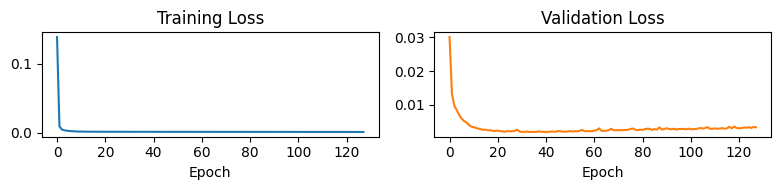

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2))
axs[0].plot(repeater.train_loss)
axs[0].set_title('Training Loss')
axs[1].plot(repeater.val_loss, color='tab:orange')
axs[1].set_title('Validation Loss')

for ax in axs.flat:
    ax.set(xlabel='Epoch', ylabel='')

fig.tight_layout()

#### Test

In [ ]:
for parameter in repeater.parameters():
  parameter.requires_grad = False
repeater.eval()

Repeater(
  (lstm): LSTM(11, 8, num_layers=2, batch_first=True)
  (linear): Linear(in_features=8, out_features=2, bias=True)
  (loss_fn): MSELoss()
)

In [ ]:
# y_test_scaled = repeater.test(generator.x_test, (generator.x_val, generator.y_val))
y_test_scaled = repeater.test(generator.x_test)
y_test = generator.y_scaler.inverse_transform(y_test_scaled)

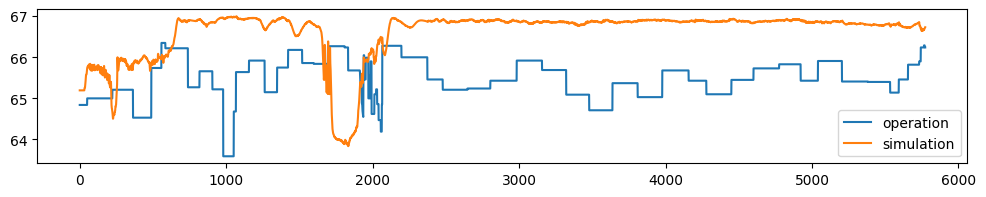

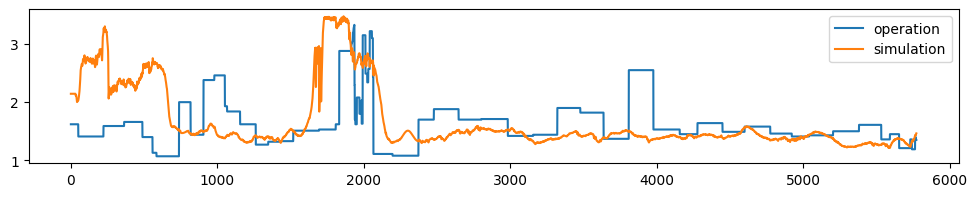

In [ ]:
for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(generator.y_scaler.inverse_transform(generator.y_test)[:, i], label='operation')
    plt.plot(y_test[:, i], label='simulation')
    plt.legend()
    plt.show()

#### Evaluate

In [ ]:
evaluator = Evaluator()

for i in range(output_size):
    metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test)[:, i], y_test[:, i])
    print(metrics_dict)

{'explained_variance_score': -1.8578227702440357, 'mean_absolute_error': 1.2663240040517763, 'mean_squared_error': 1.8958558739782487, 'root_mean_squared_error': np.float64(1.3769008221285397), 'median_absolute_error': 1.3334341430664054, 'mean_absolute_percentage_error': 0.019375895504830567, 'd2_absolute_error_score': -2.4373232705991916, 'd2_pinball_score': -2.4373232705991916, 'r2_score': -7.3462375208780095}
{'explained_variance_score': -1.4411381082041892, 'mean_absolute_error': 0.41203293436464744, 'mean_squared_error': 0.3629129474024037, 'root_mean_squared_error': np.float64(0.6024225654824059), 'median_absolute_error': 0.23933146715164189, 'mean_absolute_percentage_error': 0.2609768646080972, 'd2_absolute_error_score': -0.6492002132681778, 'd2_pinball_score': -0.6492002132681778, 'r2_score': -1.4614237557144607}


In [ ]:
evaluator = Evaluator()
metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test), y_test)
metrics_dict

{'explained_variance_score': -1.6494804392242253,
 'mean_absolute_error': 0.8391784692082239,
 'mean_squared_error': 1.1293844106903248,
 'root_mean_squared_error': np.float64(1.0627249929734055),
 'median_absolute_error': 0.7863828051090236,
 'mean_absolute_percentage_error': 0.14017638005646355,
 'd2_absolute_error_score': -1.543261741933819,
 'd2_pinball_score': -1.543261741933819,
 'r2_score': -4.403830638296492}

In [ ]:
while True:
    time.sleep(1)
    pass

KeyboardInterrupt: 

### MVV Flotation

#### Data

In [108]:
sampling_period = "1min"
# sampling_period = "2h"
interpolation_method = "linear"

df1 = pd.read_csv('./datasets/mvv/mvv_rougher_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')
df1.index = pd.to_datetime(df1.index)
df1.index.name = "date_time"
df1 = df1.resample("2h").interpolate(method=interpolation_method, limit_direction="both", axis=0)
# df1.index = pd.to_datetime(pd.date_range(start=df1.index[0], end=df1.index[-1], freq=sampling_period).strftime("%Y-%m-%d %H:%M:%S.%f"))
# df1.interpolate(method=interpolation_method, limit_direction="both", axis=0)
# df1.fillna(method='ffill', axis=0, inplace=True)


df2 = pd.read_csv('./datasets/mvv/mvv_lab_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')
df2.index = pd.to_datetime(df2.index)
df2.index.name = "date_time"
# df2 = df2.resample(sampling_period).interpolate(method=interpolation_method, limit_direction="both", axis=0)
# df2.index = pd.to_datetime(pd.date_range(start=df2.index[0], end=df2.index[-1], freq=sampling_period).strftime("%Y-%m-%d %H:%M:%S.%f"))
# df2.interpolate(method=interpolation_method, limit_direction="both", axis=0)
# df2.fillna(method='ffill', axis=0, inplace=True)

df3 = pd.read_csv('./datasets/mvv/mvv_courier_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')
df3.index = pd.to_datetime(df3.index)
df3.index.name = "date_time"
# df3 = df3.resample(sampling_period).interpolate(method=interpolation_method, limit_direction="both", axis=0)
# df3.index = pd.to_datetime(pd.date_range(start=df3.index[0], periods=df3.shape[0], freq=sampling_period).strftime("%Y-%m-%d %H:%M:%S.%f"))
# df3.interpolate(method=interpolation_method, limit_direction="both", axis=0)
# df3.fillna(method='ffill', axis=0, inplace=True)

df = pd.concat([df1, df2, df3], axis = 1)
df.sort_index(ascending=True, inplace=True)
df = df.resample(sampling_period).interpolate(method=interpolation_method, limit_direction="both", axis=0)
# df.interpolate(method=interpolation_method, limit_direction="both", axis=0, inplace=True)

df = df.iloc[:12500, :]
# df = df.iloc[:6000, :]
# df = df.iloc[:250, :]

/tmp/ipykernel_64519/1481386423.py:5: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df1 = pd.read_csv('./datasets/mvv/mvv_rougher_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')
/tmp/ipykernel_64519/1481386423.py:5: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df1 = pd.read_csv('./datasets/mvv/mvv_rougher_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')
/tmp/ipykernel_64519/1481386423.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(co

<Axes: xlabel='date_time'>

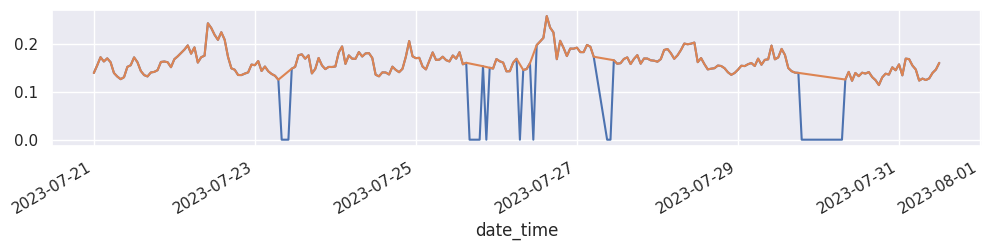

In [109]:
df31 = df3.iloc[:250, :]
df32 = df3.iloc[:250, :]

Q1 = df32.quantile(0.11, interpolation="linear")
Q3 = df32.quantile(0.89, interpolation="linear")
IQR = Q3 - Q1
df32 = df32[~((df32 < (Q1 - 1.5 * IQR)) | (df32 > (Q3 + 1.5 * IQR))).any(axis=1)]

sns.set(font_scale=1)
plt.figure(figsize=(12, 2))
df31["Rejeito Final Teor de Cu (%)"].plot()
df32["Rejeito Final Teor de Cu (%)"].plot()

<Axes: xlabel='date_time'>

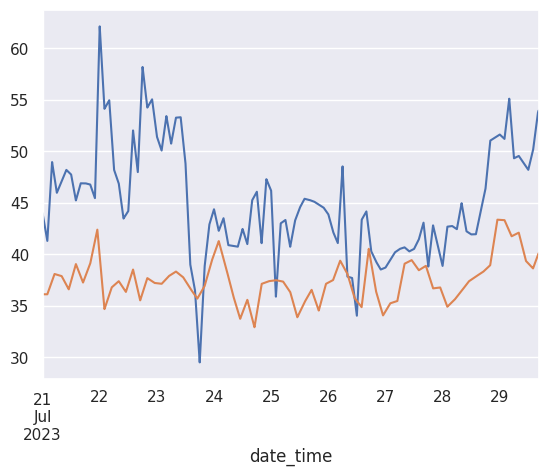

In [110]:
df["Percentual de sólidos do overflow dos ciclones (%)"].plot()
df["Alimentação da Flotação Percentual de Sólidos (%)"].plot()

In [111]:
df1 = pd.read_csv('./datasets/mvv/mvv_rougher_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')
df2 = pd.read_csv('./datasets/mvv/mvv_lab_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')
df3 = pd.read_csv('./datasets/mvv/mvv_courier_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')


df1.shape, df2.shape, df3.shape
df1.describe().T
# df3.index.values[0], df3.index.values[-1]

/tmp/ipykernel_64519/3469165638.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df1 = pd.read_csv('./datasets/mvv/mvv_rougher_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')
/tmp/ipykernel_64519/3469165638.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df1 = pd.read_csv('./datasets/mvv/mvv_rougher_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')
/tmp/ipykernel_64519/3469165638.py:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it 

,count,mean,std,min,25%,50%,75%,max
Taxa de Alimentação da Moagem Massa Úmida (t/h),6949.0,519.981015,11.584889,485.25,510.7900,516.700,528.6600,566.37
Taxa de Alimentação da Moagem Massa Seca (t/h),6949.0,502.338014,11.739275,470.04,492.9000,499.680,511.7900,545.84
pH Rougher FC-006,6949.0,9.985199,0.868447,8.38,9.4900,9.920,10.2100,13.27
pH Rougher FC-006 - Set Point,6949.0,10.000000,0.000000,10.00,10.0000,10.000,10.0000,10.00
pH Rougher CD,6949.0,10.317171,0.169096,8.04,10.2000,10.340,10.4300,11.55
pH Rougher CD - Set Point,6949.0,10.314969,0.142871,10.00,10.2000,10.300,10.4000,10.50
Vazão de Ar Rougher CD (N.m³/h),6945.0,328.447988,43.091480,82.59,298.2900,304.970,354.8200,410.96
Vazão de Ar Rougher CD - Set Point (N.m³/h),6949.0,328.605284,42.793913,250.00,300.0000,300.000,350.0000,400.00
Jg Rougher CD (cm/s),6945.0,0.671963,0.088191,0.17,0.6100,0.620,0.7300,0.84
Vazão de Ar Rougher FC-001 (N.m³/h),6946.0,333.880155,82.323159,75.86,251.3425,355.570,408.2550,445.05


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12500 entries, 2023-07-21 00:00:00 to 2023-07-29 16:19:00
Freq: min
Data columns (total 84 columns):
 #   Column                                                                                Non-Null Count  Dtype  
---  ------                                                                                --------------  -----  
 0   Taxa de Alimentação da Moagem Massa Úmida (t/h)                                       12500 non-null  float64
 1   Taxa de Alimentação da Moagem Massa Seca (t/h)                                        12500 non-null  float64
 2   pH Rougher FC-006                                                                     12500 non-null  float64
 3   pH Rougher FC-006 - Set Point                                                         12500 non-null  float64
 4   pH Rougher CD                                                                         12500 non-null  float64
 5   pH Rougher CD - Set Point           

In [113]:
df.head()

,Taxa de Alimentação da Moagem Massa Úmida (t/h),Taxa de Alimentação da Moagem Massa Seca (t/h),pH Rougher FC-006,pH Rougher FC-006 - Set Point,pH Rougher CD,pH Rougher CD - Set Point,Vazão de Ar Rougher CD (N.m³/h),Vazão de Ar Rougher CD - Set Point (N.m³/h),Jg Rougher CD (cm/s),Vazão de Ar Rougher FC-001 (N.m³/h),...,Concentrado Cleaner I Teor de Cu (%),Concentrado Cleaner II Teor de Cu (%),Concentrado Final Teor de Cu (%),Concentrado Rougher Teor de Cu (%),Concentrado Cleaner Scavanger Teor de Cu (%),Alimentação Flotração Teor de Cu (%),Rejeito Cleaner I Teor de Cu (%),Rejeito Final Teor de Cu (%),Rejeito Rougher Teor de Cu (%),Rejeito Cleaner Scavanger Teor de Cu (%)
date_time,,,,,,,,,,,,,,,,,,,,,
2023-07-21 00:00:00,517.50000,496.950,9.940,10.0,10.370000,10.3,395.710,400.0,0.810000,423.920000,...,30.520706,22.459414,23.521328,NaN,NaN,1.634042,3.284400,0.139008,0.108423,1.018938
2023-07-21 00:01:00,517.29275,496.751,9.939,10.0,10.369833,10.3,395.741,400.0,0.810083,423.962417,...,30.505144,22.463366,23.522930,NaN,NaN,1.633812,3.290356,0.139272,0.108326,1.028366
2023-07-21 00:02:00,517.08550,496.552,9.938,10.0,10.369667,10.3,395.772,400.0,0.810167,424.004833,...,30.489581,22.467319,23.524532,NaN,NaN,1.633582,3.296313,0.139535,0.108228,1.037794
2023-07-21 00:03:00,516.87825,496.353,9.937,10.0,10.369500,10.3,395.803,400.0,0.810250,424.047250,...,30.474019,22.471271,23.526134,NaN,NaN,1.633351,3.302269,0.139799,0.108131,1.047222
2023-07-21 00:04:00,516.67100,496.154,9.936,10.0,10.369333,10.3,395.834,400.0,0.810333,424.089667,...,30.458457,22.475224,23.527737,NaN,NaN,1.633121,3.308226,0.140062,0.108034,1.056650


In [114]:
columns = [
    'Taxa de Alimentação da Moagem Massa Úmida (t/h)',
    # 'Taxa de Alimentação da Moagem Massa Seca (t/h)',
    'pH Rougher FC-006',
    # 'pH Rougher FC-006 - Set Point',
    'pH Rougher CD',
    # 'pH Rougher CD - Set Point',
    'Vazão de Ar Rougher CD (N.m³/h)',
    # 'Vazão de Ar Rougher CD - Set Point (N.m³/h)',
    'Jg Rougher CD (cm/s)',
    'Vazão de Ar Rougher FC-001 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-001 - Set Point (N.m³/h)',
    'Jg Rougher FC-001 (cm/s)',
    'Vazão de Ar Rougher FC-002 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-002 - Set Point (N.m³/h)',
    'Jg Rougher FC-002 (cm/s)',
    'Vazão de Ar Rougher FC-003 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-003 - Set Point (N.m³/h)',
    'Jg Rougher FC-003 (cm/s)',
    'Vazão de Ar Rougher FC-004 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-004 - Set Point (N.m³/h)',
    'Jg Rougher FC-004 (cm/s)',
    'Vazão de Ar Rougher FC-005 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-005 - Set Point (N.m³/h)',
    'Jg Rougher FC-005 (cm/s)',
    'Vazão de Ar Rougher FC-006 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-006 - Set Point (N.m³/h)',
    'Jg Rougher FC-006 (cm/s)',
    'Camada de Espuma Rougher CD (mm)',
    # 'Camada de Espuma Rougher CD - Set Point (mm)',
    'Camada de Espuma Rougher FC-001 (mm)',
    # 'Camada de Espuma Rougher FC-001 - Set Point (mm)',
    'Camada de Espuma Rougher FC-002 (mm)',
    # 'Camada de Espuma Rougher FC-002 - Set Point (mm)',
    'Camada de Espuma Rougher FC-003/FC-004 (mm)',
    # 'Camada de Espuma Rougher FC-003/FC-004 - Set Point (mm)',
    'Camada de Espuma Rougher FC-005/FC-006 (mm)',
    # 'Camada de Espuma Rougher FC-005/FC-006 - Set Point (mm)',
    # 'Sump Operando? (reservatório de contenção dos transbordos para recircular na planta)',
    'Vazão Cal Rougher CD (L/h)',
    # 'Vazão Cal Rougher CD - Set Point (L/h)',
    'Massa Dosada Cal Rougher CD (g/t)',
    # 'Massa Dosada Cal Rougher CD - Set Point (g/t)',
    'Vazão Coletor 1 Rougher FC-002 (L/h)',
    # 'Vazão Coletor 1 Rougher FC-002 - Set Point (L/h)',
    'Massa Dosada Coletor 1 Rougher FC-002 (g/t)',
    # 'Massa Dosada Coletor 1 Rougher FC-002 - Set Point (g/t)',
    'Massa Dosada Coletor 1 Rougher FC-002 (g/t Cu)',
    # 'Massa Dosada Coletor 1 Rougher FC-002 - Set Point (g/t Cu)',
    # 'Percentual de sólidos do overflow dos ciclones (%)',
    'Granulometria do overflow dos ciclones (μm)',
    # 'Alimentação da Flotação Percentual de Sólidos (%)',
    'Alimentação da Flotação Teor de Cu (%)',
    'Alimentação da Flotação Teor de Fe (%)',
    'Alimentação da Flotação Teor de Mg (%)',
    'Alimentação da Flotação Teor de Ni (%)',
    'Alimentação da Flotação Teor de SiO2 (%)',
    # 'Rejeito Rougher Percentual de Sólidos (%)',
    'Rejeito Rougher Teor de Cu (%)',
    'Rejeito Rougher Teor de Fe (%)',
    'Rejeito Rougher Teor de Mg (%)',
    'Rejeito Rougher Teor de Ni (%)',
    'Rejeito Rougher Teor de SiO2 (%)',
    # 'Concentrado Rougher CD Percentual de Sólidos (%)',
    'Concentrado Rougher CD Teor de Cu (%)',
    'Concentrado Rougher CD Teor de Fe (%)',
    'Concentrado Rougher CD Teor de Mg (%)',
    'Concentrado Rougher CD Teor de Ni (%)',
    'Concentrado Rougher CD Teor de SiO2 (%)',
    # 'Concentrado Rougher FC-001 Percentual de Sólidos (%)',
    'Concentrado Rougher FC-001 Teor de Cu (%)',
    'Concentrado Rougher FC-001 Teor de Fe (%)',
    'Concentrado Rougher FC-001 Teor de Mg (%)',
    'Concentrado Rougher FC-001 Teor de Ni (%)',
    'Concentrado Rougher FC-001 Teor de SiO2 (%)',
    # 'Concentrado Cleaner I Teor de Cu (%)',
    # 'Concentrado Cleaner II Teor de Cu (%)',
    'Concentrado Final Teor de Cu (%)',
    # 'Concentrado Rougher Teor de Cu (%)',
    # 'Concentrado Cleaner Scavanger Teor de Cu (%)',
    # 'Alimentação Flotração Teor de Cu (%)',
    # 'Rejeito Cleaner I Teor de Cu (%)',
    'Rejeito Final Teor de Cu (%)',
    # 'Rejeito Rougher Teor de Cu (%)',
    # 'Rejeito Cleaner Scavanger Teor de Cu (%)'
 ]
columns = [
    'Taxa de Alimentação da Moagem Massa Úmida (t/h)',
    # 'Taxa de Alimentação da Moagem Massa Seca (t/h)',
    'pH Rougher FC-006',
    # 'pH Rougher FC-006 - Set Point',
    'pH Rougher CD',
    # 'pH Rougher CD - Set Point',
    'Vazão de Ar Rougher CD (N.m³/h)',
    # 'Vazão de Ar Rougher CD - Set Point (N.m³/h)',
    'Jg Rougher CD (cm/s)',
    'Vazão de Ar Rougher FC-001 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-001 - Set Point (N.m³/h)',
    'Jg Rougher FC-001 (cm/s)',
    'Vazão de Ar Rougher FC-002 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-002 - Set Point (N.m³/h)',
    'Jg Rougher FC-002 (cm/s)',
    'Vazão de Ar Rougher FC-003 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-003 - Set Point (N.m³/h)',
    'Jg Rougher FC-003 (cm/s)',
    'Vazão de Ar Rougher FC-004 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-004 - Set Point (N.m³/h)',
    'Jg Rougher FC-004 (cm/s)',
    'Vazão de Ar Rougher FC-005 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-005 - Set Point (N.m³/h)',
    'Jg Rougher FC-005 (cm/s)',
    'Vazão de Ar Rougher FC-006 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-006 - Set Point (N.m³/h)',
    'Jg Rougher FC-006 (cm/s)',
    'Camada de Espuma Rougher CD (mm)',
    # 'Camada de Espuma Rougher CD - Set Point (mm)',
    'Camada de Espuma Rougher FC-001 (mm)',
    # 'Camada de Espuma Rougher FC-001 - Set Point (mm)',
    'Camada de Espuma Rougher FC-002 (mm)',
    # 'Camada de Espuma Rougher FC-002 - Set Point (mm)',
    'Camada de Espuma Rougher FC-003/FC-004 (mm)',
    # 'Camada de Espuma Rougher FC-003/FC-004 - Set Point (mm)',
    'Camada de Espuma Rougher FC-005/FC-006 (mm)',
    # 'Camada de Espuma Rougher FC-005/FC-006 - Set Point (mm)',
    # 'Sump Operando? (reservatório de contenção dos transbordos para recircular na planta)',
    'Vazão Cal Rougher CD (L/h)',
    # 'Vazão Cal Rougher CD - Set Point (L/h)',
    'Massa Dosada Cal Rougher CD (g/t)',
    # 'Massa Dosada Cal Rougher CD - Set Point (g/t)',
    'Vazão Coletor 1 Rougher FC-002 (L/h)',
    # 'Vazão Coletor 1 Rougher FC-002 - Set Point (L/h)',
    'Massa Dosada Coletor 1 Rougher FC-002 (g/t)',
    # 'Massa Dosada Coletor 1 Rougher FC-002 - Set Point (g/t)',
    'Massa Dosada Coletor 1 Rougher FC-002 (g/t Cu)',
    # 'Massa Dosada Coletor 1 Rougher FC-002 - Set Point (g/t Cu)',
    'Percentual de sólidos do overflow dos ciclones (%)',
    'Granulometria do overflow dos ciclones (μm)',
    'Alimentação da Flotação Percentual de Sólidos (%)',
    'Alimentação da Flotação Teor de Cu (%)',
    'Alimentação da Flotação Teor de Fe (%)',
    'Alimentação da Flotação Teor de Mg (%)',
    'Alimentação da Flotação Teor de Ni (%)',
    'Alimentação da Flotação Teor de SiO2 (%)',
    # 'Rejeito Rougher Percentual de Sólidos (%)',
    'Rejeito Rougher Teor de Cu (%)',
    'Rejeito Rougher Teor de Fe (%)',
    'Rejeito Rougher Teor de Mg (%)',
    'Rejeito Rougher Teor de Ni (%)',
    'Rejeito Rougher Teor de SiO2 (%)',
    # 'Concentrado Rougher CD Percentual de Sólidos (%)',
    'Concentrado Rougher CD Teor de Cu (%)',
    'Concentrado Rougher CD Teor de Fe (%)',
    'Concentrado Rougher CD Teor de Mg (%)',
    'Concentrado Rougher CD Teor de Ni (%)',
    'Concentrado Rougher CD Teor de SiO2 (%)',
    # 'Concentrado Rougher FC-001 Percentual de Sólidos (%)',
    'Concentrado Rougher FC-001 Teor de Cu (%)',
    'Concentrado Rougher FC-001 Teor de Fe (%)',
    'Concentrado Rougher FC-001 Teor de Mg (%)',
    'Concentrado Rougher FC-001 Teor de Ni (%)',
    'Concentrado Rougher FC-001 Teor de SiO2 (%)',
    # 'Concentrado Cleaner I Teor de Cu (%)',
    # 'Concentrado Cleaner II Teor de Cu (%)',
    'Concentrado Final Teor de Cu (%)',
    # 'Concentrado Rougher Teor de Cu (%)',
    # 'Concentrado Cleaner Scavanger Teor de Cu (%)',
    # 'Alimentação Flotração Teor de Cu (%)',
    # 'Rejeito Cleaner I Teor de Cu (%)',
    'Rejeito Final Teor de Cu (%)',
    # 'Rejeito Rougher Teor de Cu (%)',
    # 'Rejeito Cleaner Scavanger Teor de Cu (%)'
 ]


input_columns = [
    # 'Taxa de Alimentação da Moagem Massa Úmida (t/h)',
    # 'Taxa de Alimentação da Moagem Massa Seca (t/h)',
    'pH Rougher FC-006',
    # 'pH Rougher CD',
    # 'Vazão de Ar Rougher CD (N.m³/h)',
    # 'Jg Rougher CD (cm/s)',
    'Vazão de Ar Rougher FC-001 (N.m³/h)',
    # 'Jg Rougher FC-001 (cm/s)',
    # 'Vazão de Ar Rougher FC-002 (N.m³/h)',
    # 'Jg Rougher FC-002 (cm/s)',
    # 'Vazão de Ar Rougher FC-003 (N.m³/h)',
    # 'Jg Rougher FC-003 (cm/s)',
    # 'Vazão de Ar Rougher FC-004 (N.m³/h)',
    # 'Jg Rougher FC-004 (cm/s)',
    # 'Vazão de Ar Rougher FC-005 (N.m³/h)',
    # 'Jg Rougher FC-005 (cm/s)',
    # 'Vazão de Ar Rougher FC-006 (N.m³/h)',
    # 'Jg Rougher FC-006 (cm/s)',
    # 'Camada de Espuma Rougher CD (mm)',
    # 'Camada de Espuma Rougher FC-001 (mm)',
    # 'Camada de Espuma Rougher FC-002 (mm)',
    'Camada de Espuma Rougher FC-003/FC-004 (mm)',
    # 'Camada de Espuma Rougher FC-005/FC-006 (mm)',
    # 'Vazão Cal Rougher CD (L/h)',
    # 'Massa Dosada Cal Rougher CD (g/t)',
    'Vazão Coletor 1 Rougher FC-002 (L/h)',
    # 'Massa Dosada Coletor 1 Rougher FC-002 (g/t)',
    # 'Massa Dosada Coletor 1 Rougher FC-002 (g/t Cu)',
    # 'Percentual de sólidos do overflow dos ciclones (%)',
    'Granulometria do overflow dos ciclones (μm)',
    # 'Alimentação da Flotação Percentual de Sólidos (%)',
    'Alimentação da Flotação Teor de Cu (%)',
    # 'Alimentação da Flotação Teor de Fe (%)',
    # 'Alimentação da Flotação Teor de Mg (%)',
    # 'Alimentação da Flotação Teor de Ni (%)',
    # 'Alimentação da Flotação Teor de SiO2 (%)',
]

output_columns = [
    # 'Concentrado Rougher CD Percentual de Sólidos (%)',
    # 'Concentrado Rougher CD Teor de Cu (%)',
    # 'Concentrado Rougher CD Teor de Fe (%)',
    # 'Concentrado Rougher CD Teor de Mg (%)',
    # 'Concentrado Rougher CD Teor de Ni (%)',
    # 'Concentrado Rougher CD Teor de SiO2 (%)',
    # 'Concentrado Rougher FC-001 Percentual de Sólidos (%)',
    # 'Concentrado Rougher FC-001 Teor de Cu (%)',
    # 'Concentrado Rougher FC-001 Teor de Fe (%)',
    # 'Concentrado Rougher FC-001 Teor de Mg (%)',
    # 'Concentrado Rougher FC-001 Teor de Ni (%)',
    # 'Concentrado Rougher FC-001 Teor de SiO2 (%)',
    'Concentrado Final Teor de Cu (%)',
    'Rejeito Final Teor de Cu (%)',
]

df = df[columns].astype(float)

# IQR
# Q1 = df.quantile(0.1, interpolation="midpoint")
# Q3 = df.quantile(0.9, interpolation="midpoint")
# IQR = Q3 - Q1
# df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

df = df.resample(sampling_period).interpolate(method=interpolation_method, limit_direction="both", axis=0)

<Axes: >

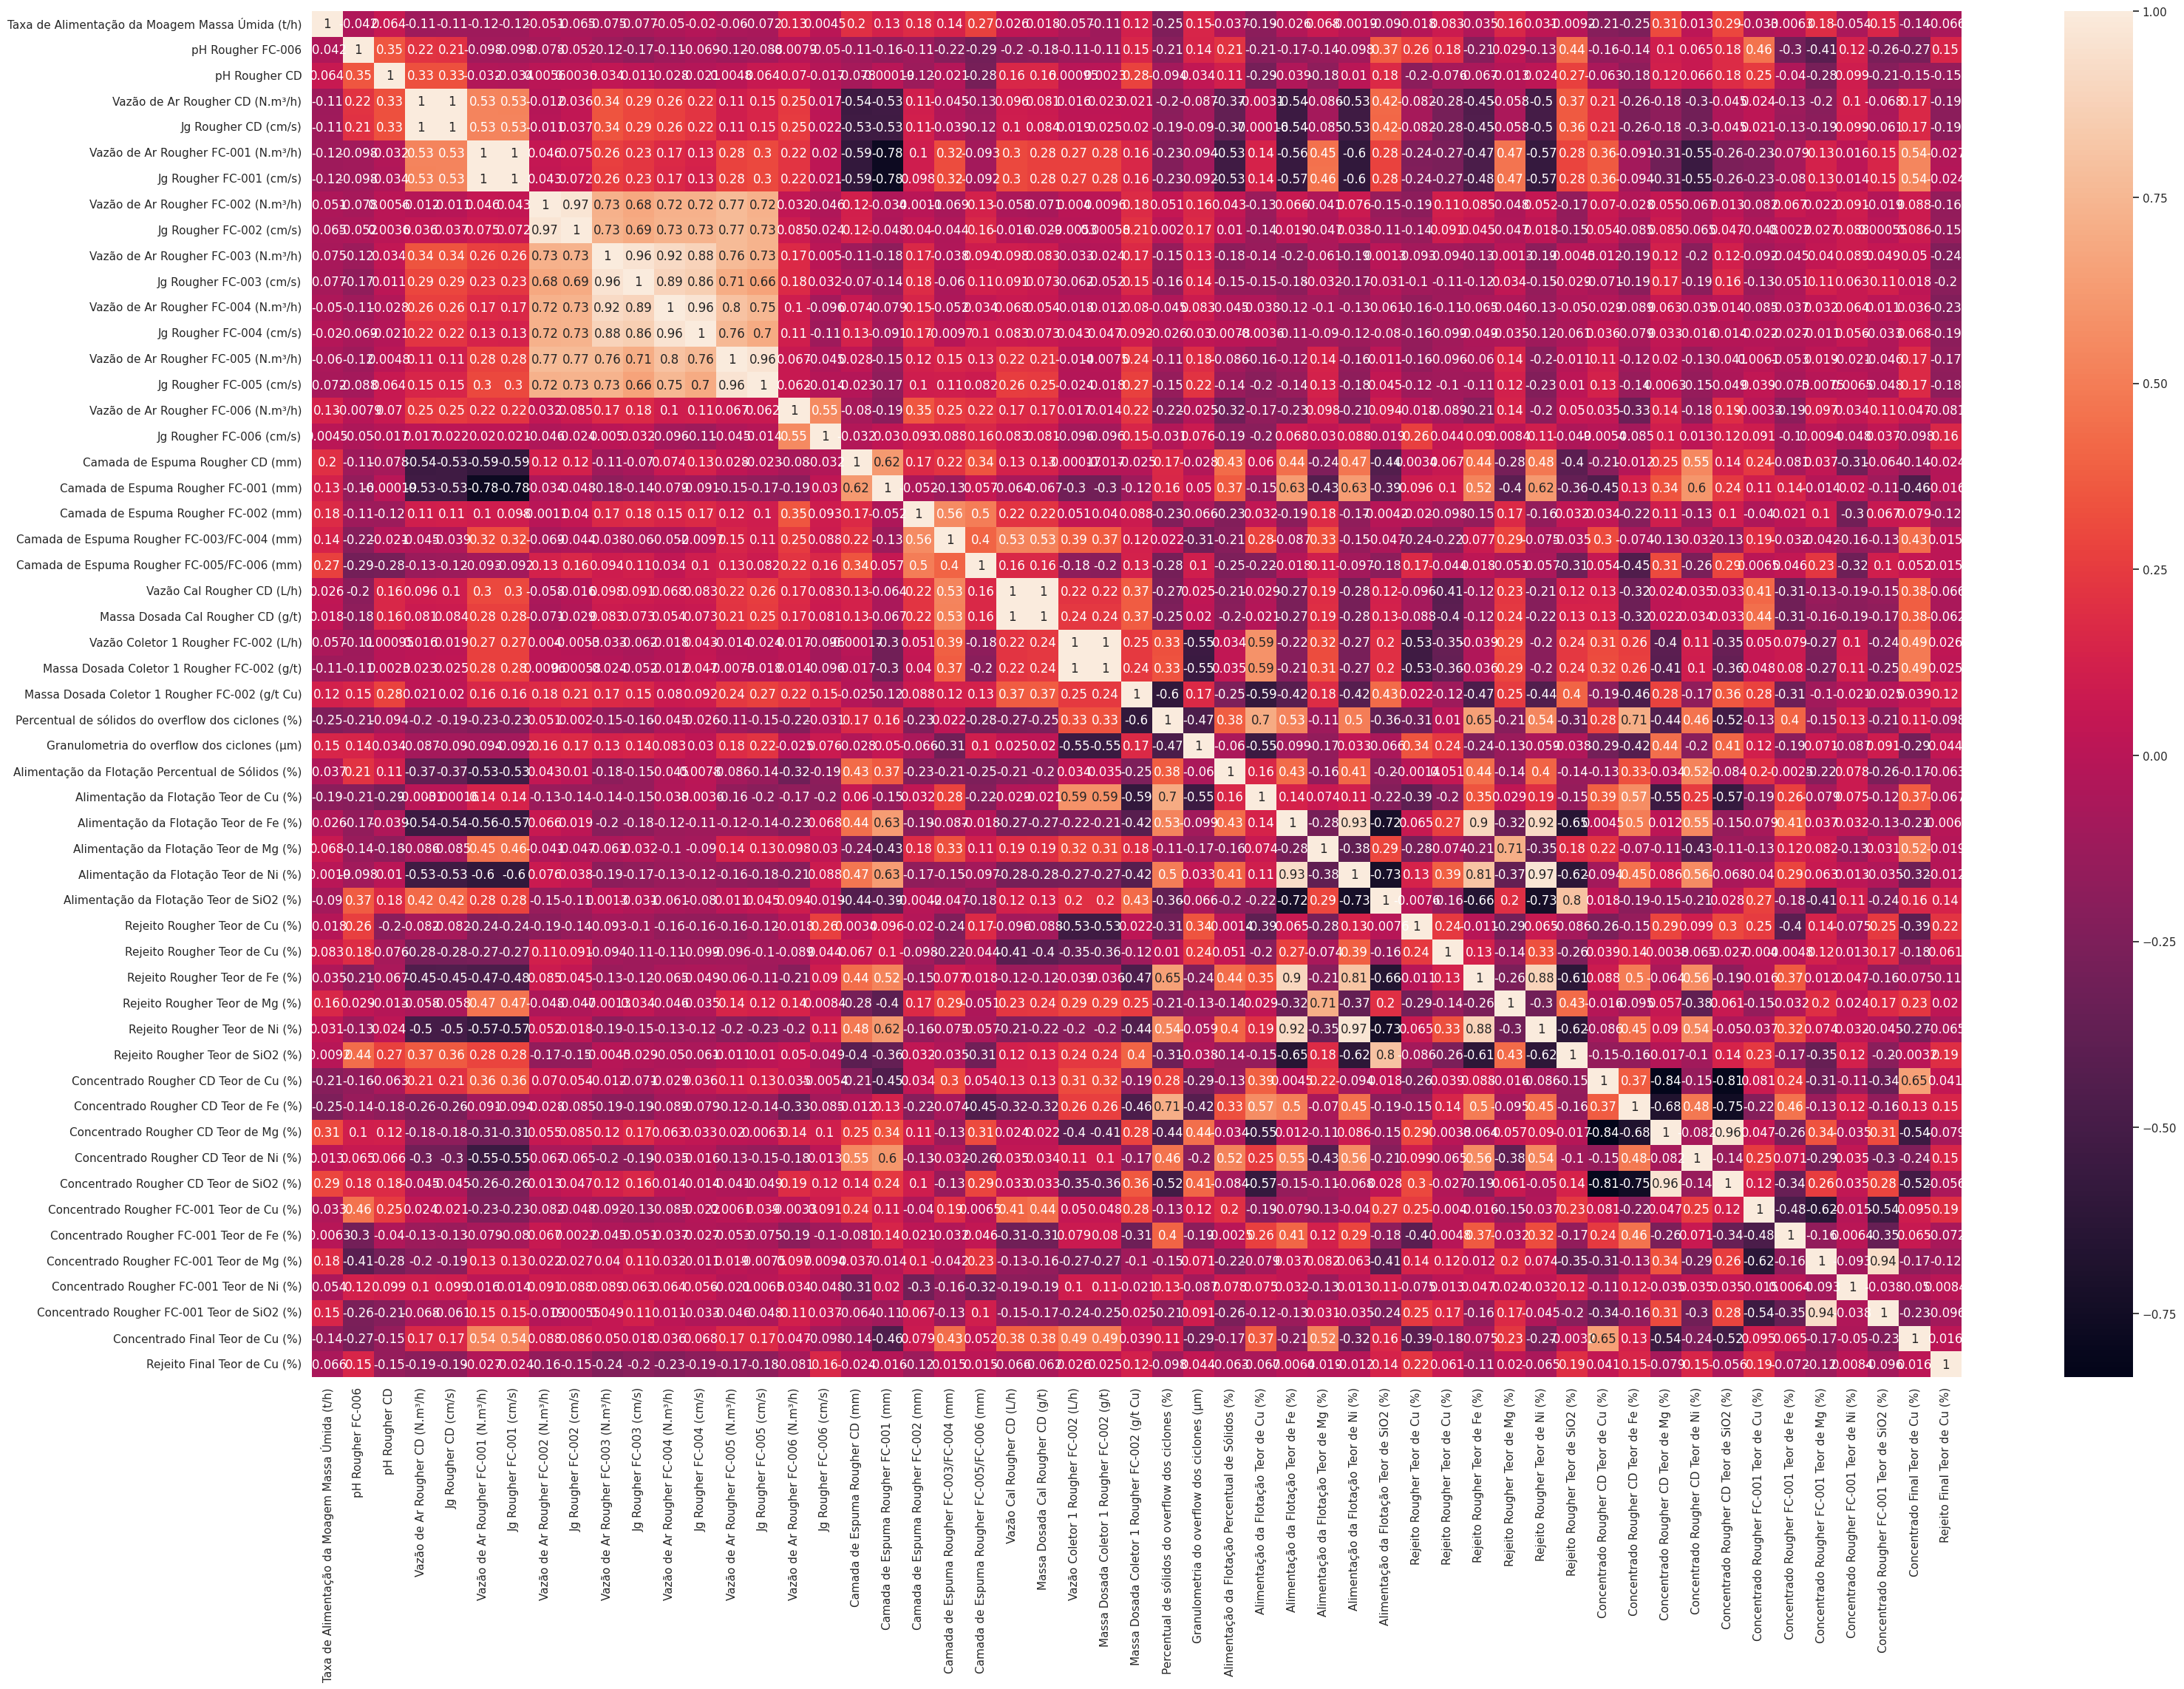

In [115]:
df_corr = df.corr(method="pearson")

plt.figure(figsize=(36, 24))
sns.heatmap(df_corr, annot=True)

<Axes: >

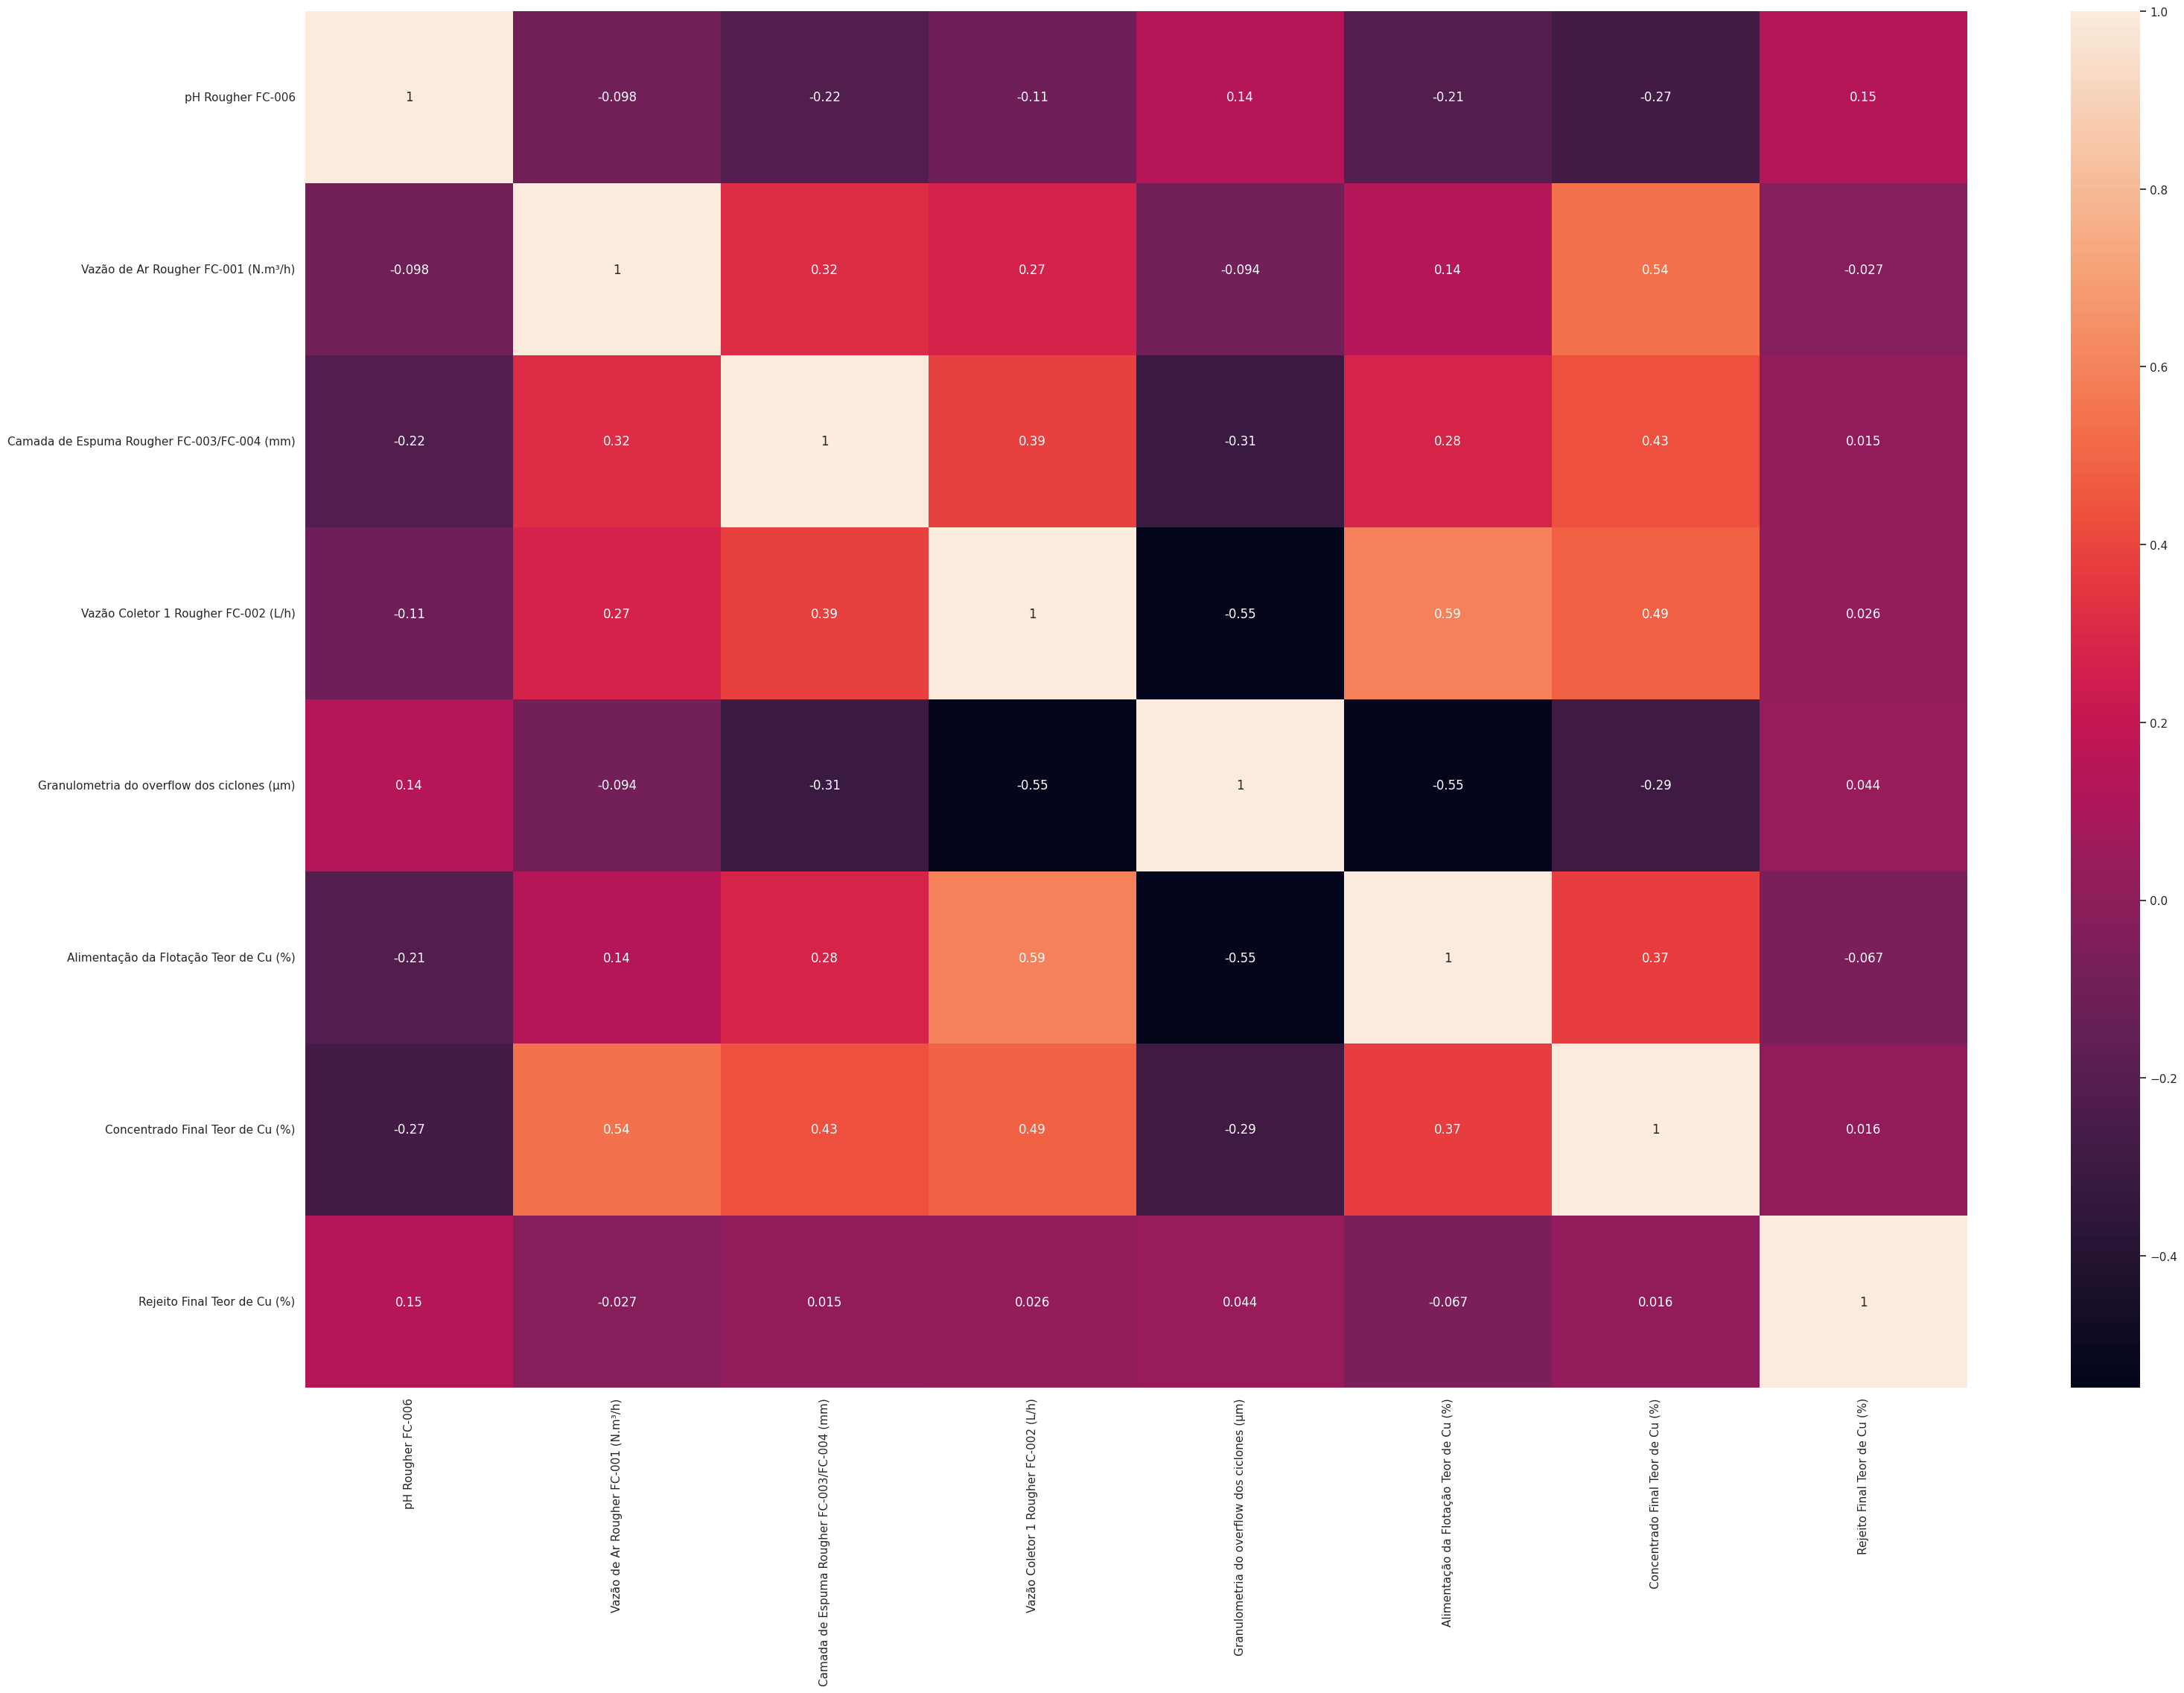

In [116]:
df_corr = df[input_columns + output_columns].corr(method="pearson")

plt.figure(figsize=(36, 24))

# sns.set(font_scale=2)
sns.heatmap(df_corr, annot=True)

In [117]:
df_corr[output_columns][np.abs(df_corr[output_columns]) >= 0.1]

,Concentrado Final Teor de Cu (%),Rejeito Final Teor de Cu (%)
pH Rougher FC-006,-0.270929,0.146749
Vazão de Ar Rougher FC-001 (N.m³/h),0.539423,NaN
Camada de Espuma Rougher FC-003/FC-004 (mm),0.433665,NaN
Vazão Coletor 1 Rougher FC-002 (L/h),0.485934,NaN
Granulometria do overflow dos ciclones (μm),-0.294290,NaN
Alimentação da Flotação Teor de Cu (%),0.374312,NaN
Concentrado Final Teor de Cu (%),1.000000,NaN
Rejeito Final Teor de Cu (%),NaN,1.000000


In [118]:
input_size = len(input_columns)
output_size = len(output_columns)

x = df[input_columns].values
y = df[output_columns].values

In [119]:
df[input_columns + output_columns].describe()

,pH Rougher FC-006,Vazão de Ar Rougher FC-001 (N.m³/h),Camada de Espuma Rougher FC-003/FC-004 (mm),Vazão Coletor 1 Rougher FC-002 (L/h),Granulometria do overflow dos ciclones (μm),Alimentação da Flotação Teor de Cu (%),Concentrado Final Teor de Cu (%),Rejeito Final Teor de Cu (%)
count,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000
mean,9.716763,392.416910,303.731409,11.872423,111.623708,1.150245,22.121111,0.155428
std,0.335838,61.186472,12.637583,1.812013,7.785225,0.255126,1.820262,0.042521
min,8.840000,203.440000,270.810000,3.230000,81.340000,0.784000,17.852615,0.000000
25%,9.450229,400.292917,295.516917,10.592375,106.239875,0.947533,20.992883,0.146243
50%,9.737750,406.530833,301.809292,11.973333,112.531625,1.103600,21.983131,0.162329
75%,9.995333,428.752687,313.293542,13.376000,117.313750,1.236858,23.182939,0.175052
max,10.370000,440.580000,341.780000,18.200000,126.930000,1.927000,27.473946,0.257744


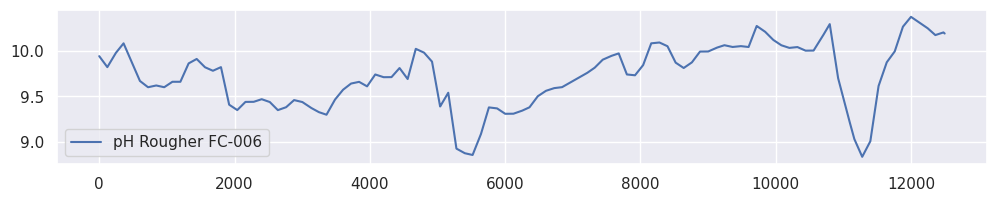

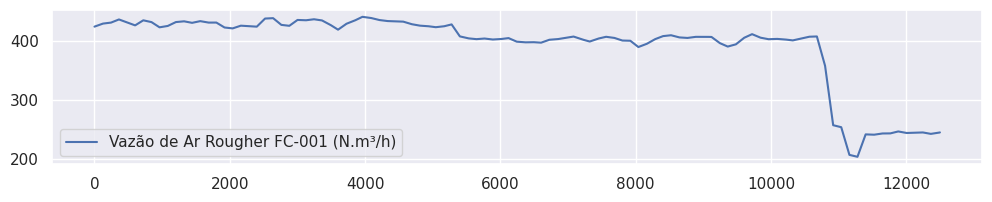

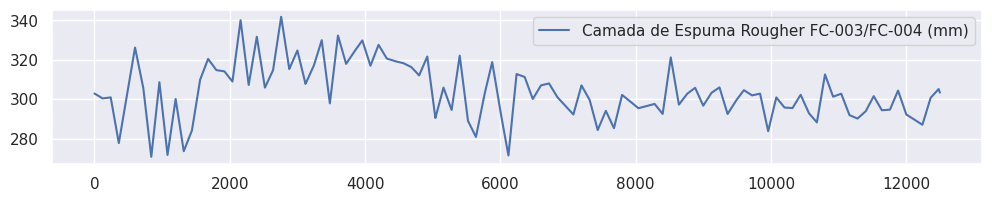

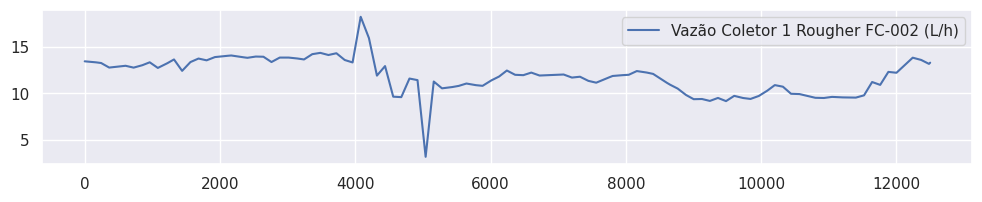

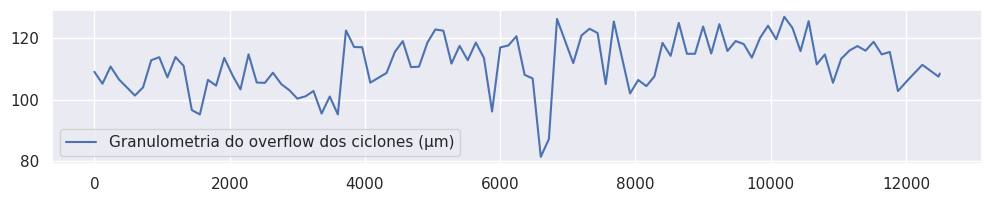

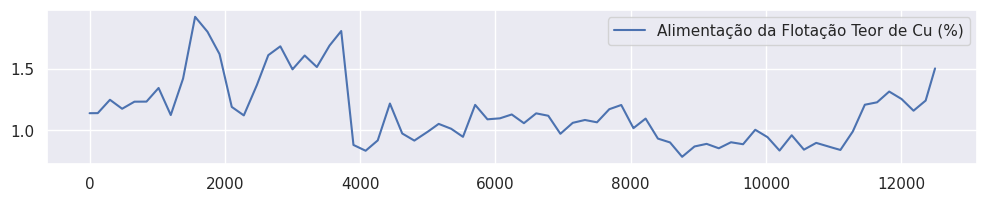

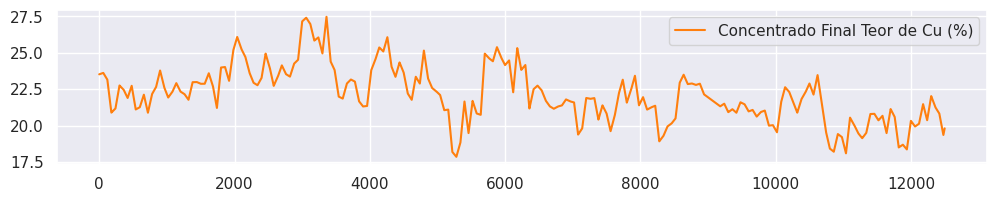

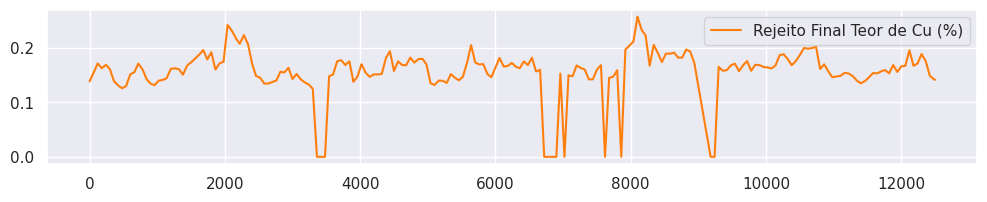

In [120]:
for i in range(x.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(x[:, i], label=input_columns[i])
    plt.legend()
    plt.show()

for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(y[:, i], label=output_columns[i], color="tab:orange")
    plt.legend()
    plt.show()

In [121]:
batch_size = 2**5
lag = 2**5

generator = Generator()
train_dataloader, val_dataloader = generator.generate_dataloaders(x, y, lag, batch_size)

#### Model

In [122]:
config = {
    "input_size": input_size + output_size,
    "output_size": output_size,
    "hidden_size": 2**5,
    "num_layers": 2**1,
    "learning_rate": 1e-3,
    "dropout": 0,
    "lag": lag,
    "epochs": 2**5
}

In [123]:
repeater = Repeater(**config).to(device)
print(repeater)

Repeater(
  (lstm): LSTM(8, 32, num_layers=2, batch_first=True)
  (linear): Linear(in_features=32, out_features=2, bias=True)
  (loss_fn): MSELoss()
)


#### Train

In [124]:
%%time
repeater.fit(train_dataloader, val_dataloader)

Epoch 1/32
195/195 [====================================================================================================] 100%
0.0039s 0.0039s/step - train_loss: 0.02457178 - val_loss: 0.03066250 

Epoch 2/32
195/195 [====================================================================================================] 100%
0.0074s 0.0037s/step - train_loss: 0.01262668 - val_loss: 0.02255778 

Epoch 3/32
195/195 [====================================================================================================] 100%
0.0108s 0.0036s/step - train_loss: 0.00854848 - val_loss: 0.01875965 

Epoch 4/32
195/195 [====================================================================================================] 100%
0.0143s 0.0036s/step - train_loss: 0.00648254 - val_loss: 0.01671686 

Epoch 5/32
195/195 [====================================================================================================] 100%
0.0188s 0.0038s/step - train_loss: 0.00522521 - val_loss: 0.01495702 

Epoch 6/32

In [125]:
repeater.x_min_ = generator.x_scaler.min_.tolist()
repeater.x_scale_ = generator.x_scaler.scale_.tolist()
repeater.x_data_min_ = generator.x_scaler.data_min_.tolist()
repeater.x_data_max_ = generator.x_scaler.data_max_.tolist()
repeater.x_data_range_ = generator.x_scaler.data_range_.tolist()
repeater.x_n_features_in_ = generator.x_scaler.n_features_in_
repeater.x_n_samples_seen_ = generator.x_scaler.n_samples_seen_

repeater.y_min_ = generator.y_scaler.min_.tolist()
repeater.y_scale_ = generator.y_scaler.scale_.tolist()
repeater.y_data_min_ = generator.y_scaler.data_min_.tolist()
repeater.y_data_max_ = generator.y_scaler.data_max_.tolist()
repeater.y_data_range_ = generator.y_scaler.data_range_.tolist()
repeater.y_n_features_in_ = generator.y_scaler.n_features_in_
repeater.y_n_samples_seen_ = generator.y_scaler.n_samples_seen_

model_path = "./models/{}.pt".format(uuid.uuid4())
torch.jit.script(repeater).save(model_path)

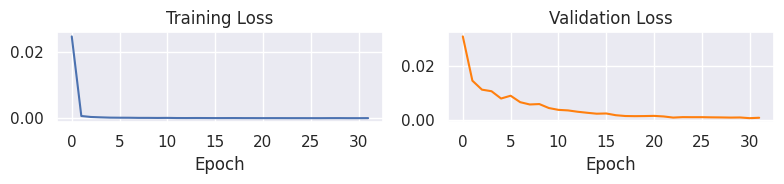

In [126]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2))
axs[0].plot(repeater.train_loss)
axs[0].set_title('Training Loss')
axs[1].plot(repeater.val_loss, color='tab:orange')
axs[1].set_title('Validation Loss')

for ax in axs.flat:
    ax.set(xlabel='Epoch', ylabel='')

fig.tight_layout()

#### Test

In [127]:
for parameter in repeater.parameters():
  parameter.requires_grad = False
repeater.eval()

Repeater(
  (lstm): LSTM(8, 32, num_layers=2, batch_first=True)
  (linear): Linear(in_features=32, out_features=2, bias=True)
  (loss_fn): MSELoss()
)

In [128]:
# y_test_scaled = repeater.test(generator.x_test, (generator.x_val, generator.y_val))
y_test_scaled = repeater.test(generator.x_test)
y_test = generator.y_scaler.inverse_transform(y_test_scaled)

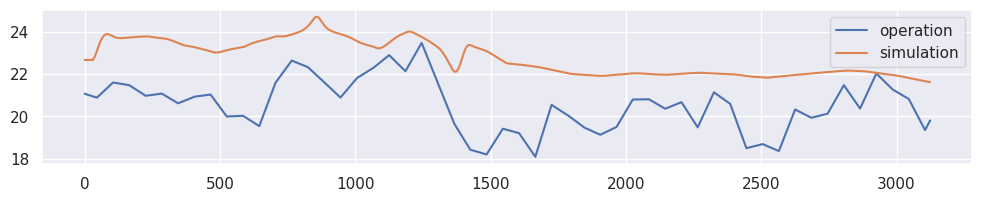

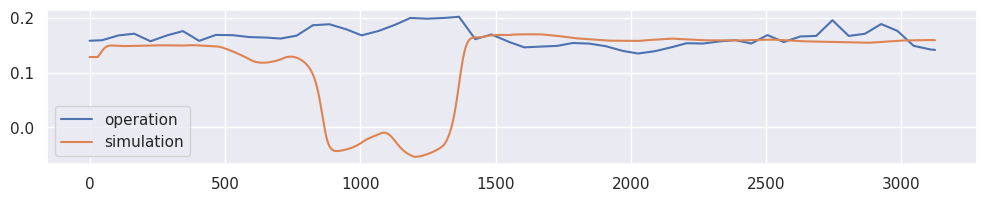

In [129]:
for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(generator.y_scaler.inverse_transform(generator.y_test)[:, i], label='operation')
    plt.plot(y_test[:, i], label='simulation')
    plt.legend()
    plt.show()

#### Evaluate

In [130]:
evaluator = Evaluator()

for i in range(output_size):
    metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test)[:, i], y_test[:, i])
    print(metrics_dict)

{'explained_variance_score': 0.2924423914208224, 'mean_absolute_error': 2.203029258982336, 'mean_squared_error': 5.820665847155851, 'root_mean_squared_error': np.float64(2.4126056136790885), 'median_absolute_error': 2.1544204076131095, 'mean_absolute_percentage_error': 0.10960608244056887, 'd2_absolute_error_score': -1.335872952088868, 'd2_pinball_score': -1.335872952088868, 'r2_score': -3.2575596901689607}
{'explained_variance_score': -25.10429800136825, 'mean_absolute_error': 0.051604410401882864, 'mean_squared_error': 0.008353867705127135, 'root_mean_squared_error': np.float64(0.09139949510323968), 'median_absolute_error': 0.019591882824898155, 'mean_absolute_percentage_error': 0.28595029127873467, 'd2_absolute_error_score': -3.196328861808219, 'd2_pinball_score': -3.196328861808219, 'r2_score': -32.50939772422439}


In [131]:
evaluator = Evaluator()
metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test), y_test)
metrics_dict

{'explained_variance_score': -12.405927804973755,
 'mean_absolute_error': 1.1273168346921105,
 'mean_squared_error': 2.9145098574304775,
 'root_mean_squared_error': np.float64(1.707193561793881),
 'median_absolute_error': 1.0870061452190038,
 'mean_absolute_percentage_error': 0.19777818685965176,
 'd2_absolute_error_score': -2.2661009069485445,
 'd2_pinball_score': -2.2661009069485445,
 'r2_score': -17.883478707196716}

Text(0, 0.5, 'Rejeito Final\n Teor de Cu (%)')

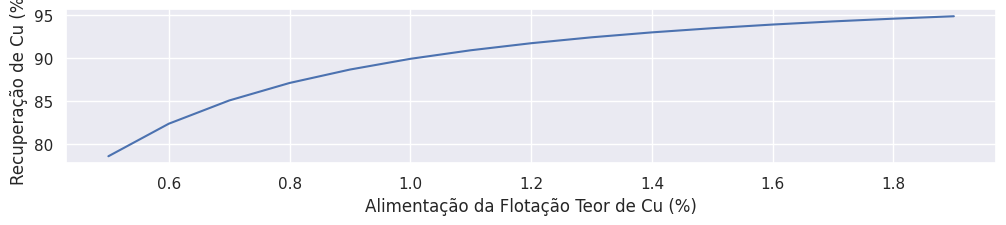

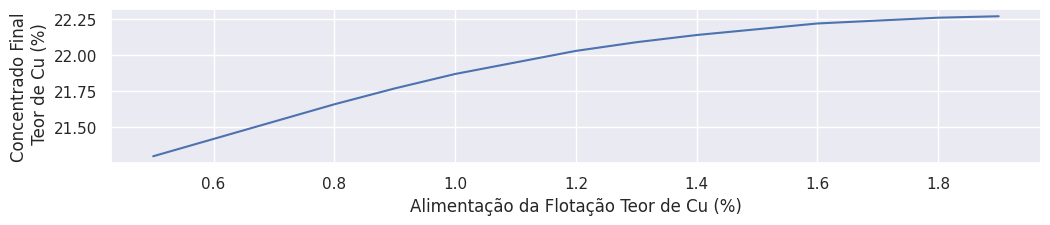

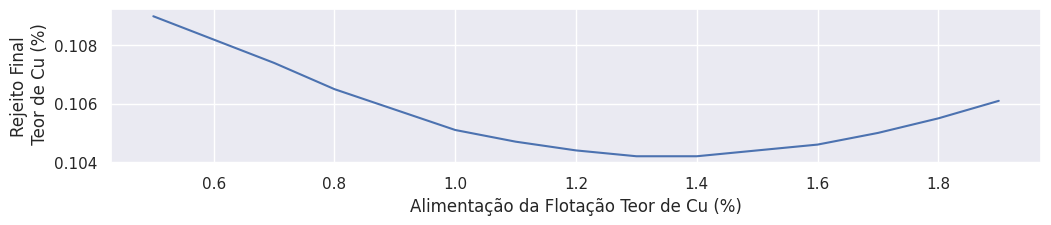

In [132]:
# recovery = concentrate / feed * (feed - reject) / (concentrate - reject)

def get_recovery(feed, concentrate, reject):
    recovery = concentrate / feed * (feed - reject) / (concentrate - reject)

    return recovery

feed = np.asarray([0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
concentrate = np.asarray([21.3, 21.42, 21.54, 21.66, 21.77, 21.87, 21.95, 22.03, 22.09, 22.14, 22.18, 22.22, 22.24, 22.26, 22.27])
reject = np.asarray([0.109, 0.1082, 0.1074, 0.1065, 0.1058, 0.1051, 0.1047, 0.1044, 0.1042, 0.1042, 0.1044, 0.1046, 0.105, 0.1055, 0.1061])

recovery = get_recovery(feed, concentrate, reject)

plt.figure(figsize=(12, 2))
plt.plot(feed, recovery*100)
plt.xlabel("Alimentação da Flotação Teor de Cu (%)")
plt.ylabel("Recuperação de Cu (%)")

plt.figure(figsize=(12, 2))
plt.plot(feed, concentrate)
plt.xlabel("Alimentação da Flotação Teor de Cu (%)")
plt.ylabel("Concentrado Final\n Teor de Cu (%)")

plt.figure(figsize=(12, 2))
plt.plot(feed, reject)
plt.xlabel("Alimentação da Flotação Teor de Cu (%)")
plt.ylabel("Rejeito Final\n Teor de Cu (%)")

In [133]:
while True:
    time.sleep(1)
    pass

KeyboardInterrupt: 

### MVV Grinding

#### Data

In [3]:
df = pd.read_csv('./datasets/mvv/mvv_grinding.csv', sep=";", decimal='.', parse_dates=["Timestamp"], infer_datetime_format=True).set_index('Timestamp').astype(float)
df.index = pd.to_datetime(df.index)
# df.index = pd.to_datetime(pd.date_range(start=df.index[0], periods=df.shape[0], freq="5min").strftime("%Y-%m-%d %H:%M:%S.%f"))
df = df.resample("1min").interpolate(method="linear", limit_direction="both", axis=0)
df.index.name = "date_time"
df.interpolate(method="linear", limit_direction="both", axis=0)
df.fillna(method='ffill', axis=0, inplace=True)

# df = df.iloc[5000:20000, :]
print(df.shape)

(51900, 10)


/tmp/ipykernel_217981/3684570498.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv('./datasets/mvv/mvv_grinding.csv', sep=";", decimal='.', parse_dates=["Timestamp"], infer_datetime_format=True).set_index('Timestamp').astype(float)
/tmp/ipykernel_217981/3684570498.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', axis=0, inplace=True)


In [5]:
# Z-score
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

df = df.resample("1min").interpolate(method="linear", limit_direction="both", axis=0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 51600 entries, 2025-12-01 06:57:00 to 2026-01-06 02:56:00
Freq: min
Data columns (total 10 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   SystemArchive\ 2201-WIC-001/2201-WIC-001.PV#Value      51600 non-null  float64
 1   SystemArchive\ 2202-DIC-0001/2202-DIC-0001.PV#Value    51600 non-null  float64
 2   SystemArchive\ 2202-FIC-0003/2202-FIC-0003.PV#Value    51600 non-null  float64
 3   SystemArchive\ 2202-FIT-0001/2202-FIT-0001.PV#Value    51600 non-null  float64
 4   SystemArchive\ 2202-FIT-0002/2202-FIT-0002.PV#Value    51600 non-null  float64
 5   SystemArchive\ 2202-PIC-0101/2202-PIC-0101.PV#Value    51600 non-null  float64
 6   SystemArchive\ 2202-PP-001/2202-PP-001.RbkOut#Value    51600 non-null  float64
 7   SystemArchive\ 2202-PP-001/2202-PP-001.UserAna1#Value  51600 non-null  float64
 8   S

In [7]:
df.head()

,SystemArchive\ 2201-WIC-001/2201-WIC-001.PV#Value,SystemArchive\ 2202-DIC-0001/2202-DIC-0001.PV#Value,SystemArchive\ 2202-FIC-0003/2202-FIC-0003.PV#Value,SystemArchive\ 2202-FIT-0001/2202-FIT-0001.PV#Value,SystemArchive\ 2202-FIT-0002/2202-FIT-0002.PV#Value,SystemArchive\ 2202-PIC-0101/2202-PIC-0101.PV#Value,SystemArchive\ 2202-PP-001/2202-PP-001.RbkOut#Value,SystemArchive\ 2202-PP-001/2202-PP-001.UserAna1#Value,SystemArchive\ 2202-PP-002/2202-PP-002.RbkOut#Value,SystemArchive\ 2202-PP-002/2202-PP-002.UserAna1#Value
date_time,,,,,,,,,,
2025-12-01 06:57:00,531.957853,1.721216,160.511629,1845.159953,581.379704,1.208888,0.0,0.866667,94.903333,106.800001
2025-12-01 06:58:00,531.516772,1.722530,160.377881,1851.163207,576.949264,1.207133,0.0,0.879167,94.883750,106.779167
2025-12-01 06:59:00,531.075691,1.723844,160.244133,1857.166461,572.518824,1.205378,0.0,0.891667,94.864167,106.758334
2025-12-01 07:00:00,530.634609,1.725158,160.110384,1863.169715,568.088384,1.203623,0.0,0.904167,94.844583,106.737501
2025-12-01 07:01:00,530.193528,1.726472,159.976636,1869.172970,563.657944,1.201868,0.0,0.916667,94.825000,106.716667


In [8]:
columns = [
    "2201-WIC-001/2201-WIC-001.PV",
    "2202-DIC-0001/2202-DIC-0001.PV",
    "2202-FIC-0003/2202-FIC-0003.PV",
    "2202-FIT-0001/2202-FIT-0001.PV",
    "2202-FIT-0002/2202-FIT-0002.PV",
    "2202-PIC-0101/2202-PIC-0101.PV",
    "2202-PP-001/2202-PP-001.RbkOut",
    "2202-PP-001/2202-PP-001.UserAna1",
    "2202-PP-002/2202-PP-002.RbkOut",
    "2202-PP-002/2202-PP-002.UserAna1",
]

columns = [
    "Feed Rate",
    "Density",
    "Water Input Flow Mill",
    "Cyclone Flow",
    "Water Flow Mill Box",
    "Cyclone Pressure",
    "Speed 1",
    "Current 1",
    "Speed 2",
    "Current 2",
]

input_columns = [
    "Feed Rate",
    "Density",
    "Water Input Flow Mill",
    "Water Flow Mill Box",
    'Cyclone Pressure',
    # "Speed 1",
    # "Current 1",
    # "Speed 2",
    # "Current 2",
]

output_columns = [
    'Cyclone Flow',
]

df.index.names = ["date_time"]
df.columns = columns

<Axes: >

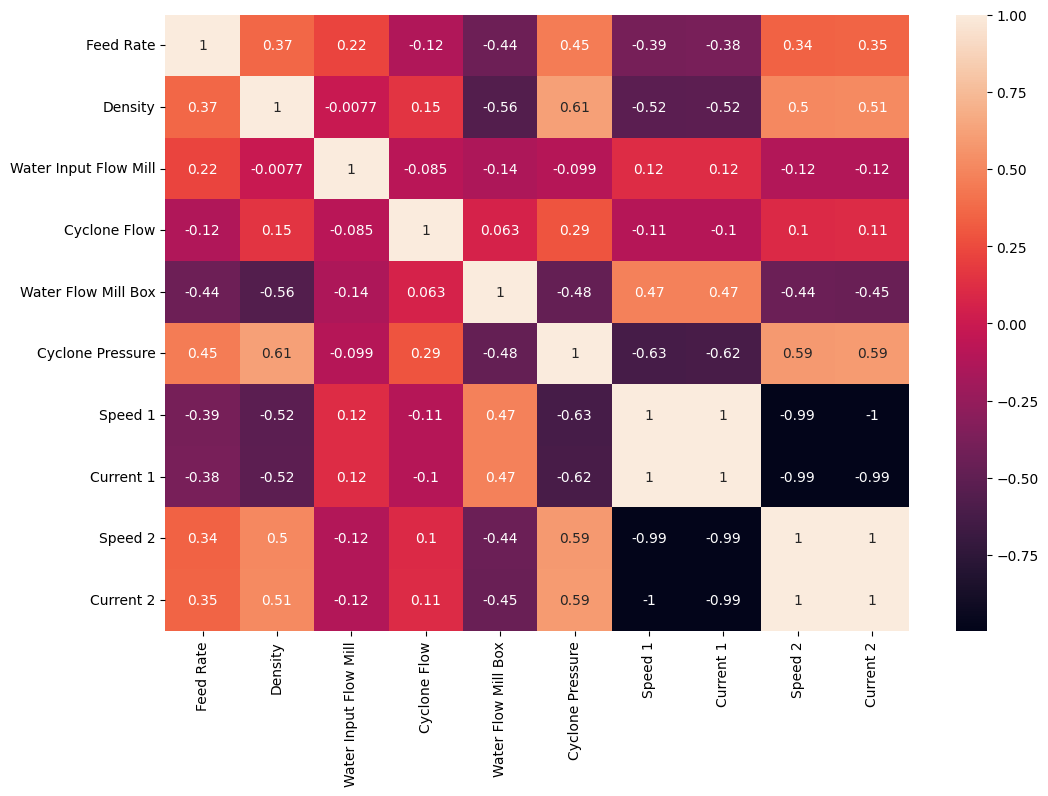

In [9]:
df_corr = df.corr(method="pearson")

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr, annot=True)

In [9]:
input_size = len(input_columns)
output_size = len(output_columns)

x = df[input_columns].values
y = df[output_columns].values

In [10]:
df[input_columns + output_columns].describe()

,Feed Rate,Density,Water Input Flow Mill,Water Flow Mill Box,Cyclone Pressure,Cyclone Flow
count,10988.000000,10988.000000,10988.000000,10988.000000,10988.000000,10988.000000
mean,556.503706,1.677551,229.792458,805.510374,1.189483,2076.928263
std,22.090776,0.043202,27.804296,85.524191,0.031792,74.955766
min,459.806131,1.523455,141.334947,476.842376,0.978887,1737.743836
25%,538.435368,1.646115,207.747198,749.032677,1.190984,2035.525576
50%,560.095438,1.676418,222.900204,809.253493,1.198372,2077.994832
75%,575.478675,1.706111,246.954809,860.953539,1.205415,2121.184846
max,635.452771,1.814832,305.982594,1066.040426,1.242250,2332.519539


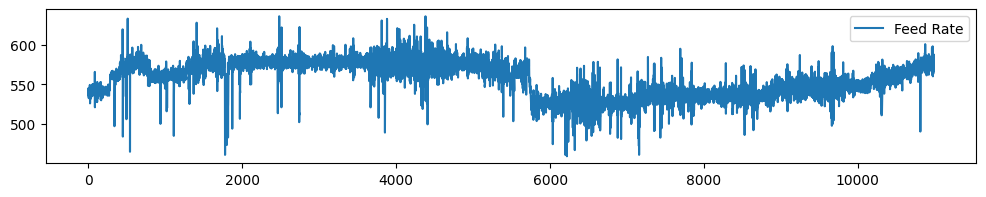

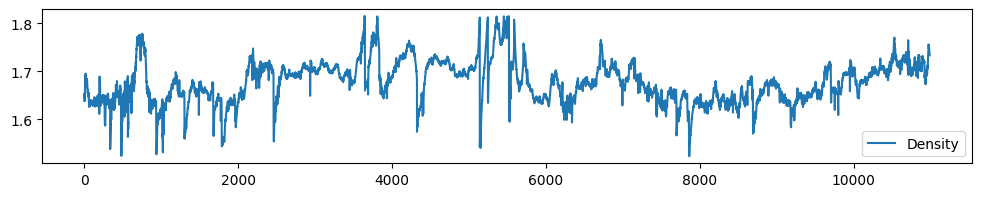

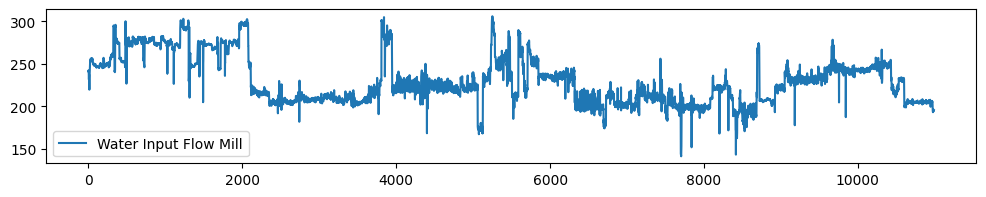

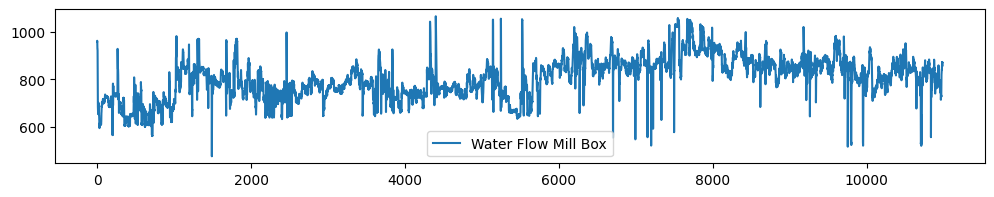

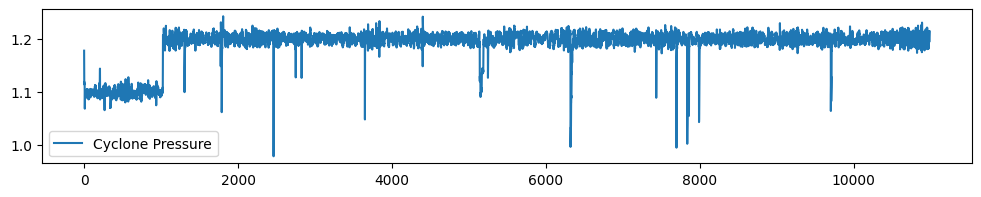

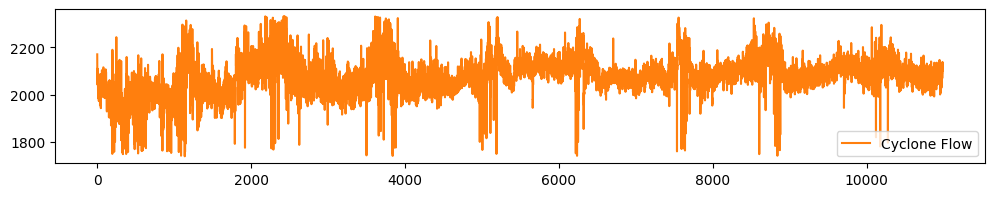

In [11]:
for i in range(x.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(x[:, i], label=input_columns[i])
    plt.legend()
    plt.show()

for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(y[:, i], label=output_columns[i], color="tab:orange")
    plt.legend()
    plt.show()

In [ ]:
batch_size = 2**5
lag = 2**5

generator = Generator()
train_dataloader, val_dataloader = generator.generate_dataloaders(x, y, lag, batch_size)

#### Model

In [16]:
config = {
    "input_size": input_size + output_size,
    "output_size": output_size,
    "hidden_size": 2**5,
    "num_layers": 2**1,
    "learning_rate": 1e-3,
    "dropout": 0.5,
    "lag": lag,
    "epochs": 2**6
}

In [17]:
repeater = Repeater(**config).to(device)
print(repeater)

Repeater(
  (lstm): LSTM(6, 32, num_layers=2, batch_first=True, dropout=0.5)
  (linear): Linear(in_features=32, out_features=1, bias=True)
  (loss_fn): MSELoss()
)


#### Train

In [18]:
%%time
repeater.fit(train_dataloader, val_dataloader)

Epoch 1/64
43/43 [====================================================================================================] 100%
0.0165s 0.0165s/step - train_loss: 0.06707021 - val_loss: 0.03339862 

Epoch 2/64
43/43 [====================================================================================================] 100%
0.0303s 0.0151s/step - train_loss: 0.05649183 - val_loss: 0.02840129 

Epoch 3/64
43/43 [====================================================================================================] 100%
0.0419s 0.0140s/step - train_loss: 0.05237337 - val_loss: 0.02663434 

Epoch 4/64
43/43 [====================================================================================================] 100%
0.0531s 0.0133s/step - train_loss: 0.05027611 - val_loss: 0.02563550 

Epoch 5/64
43/43 [====================================================================================================] 100%
0.0652s 0.0130s/step - train_loss: 0.04893065 - val_loss: 0.02521959 

Epoch 6/64
43/43 [==

In [19]:
repeater.x_min_ = generator.x_scaler.min_.tolist()
repeater.x_scale_ = generator.x_scaler.scale_.tolist()
repeater.x_data_min_ = generator.x_scaler.data_min_.tolist()
repeater.x_data_max_ = generator.x_scaler.data_max_.tolist()
repeater.x_data_range_ = generator.x_scaler.data_range_.tolist()
repeater.x_n_features_in_ = generator.x_scaler.n_features_in_
repeater.x_n_samples_seen_ = generator.x_scaler.n_samples_seen_

repeater.y_min_ = generator.y_scaler.min_.tolist()
repeater.y_scale_ = generator.y_scaler.scale_.tolist()
repeater.y_data_min_ = generator.y_scaler.data_min_.tolist()
repeater.y_data_max_ = generator.y_scaler.data_max_.tolist()
repeater.y_data_range_ = generator.y_scaler.data_range_.tolist()
repeater.y_n_features_in_ = generator.y_scaler.n_features_in_
repeater.y_n_samples_seen_ = generator.y_scaler.n_samples_seen_

# model_path = "./models/{}.pt".format(uuid.uuid4())
# torch.jit.script(repeater).save(model_path)

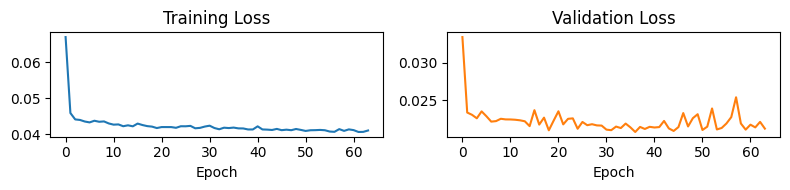

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2))
axs[0].plot(repeater.train_loss)
axs[0].set_title('Training Loss')
axs[1].plot(repeater.val_loss, color='tab:orange')
axs[1].set_title('Validation Loss')

for ax in axs.flat:
    ax.set(xlabel='Epoch', ylabel='')

fig.tight_layout()

#### Test

In [21]:
for parameter in repeater.parameters():
  parameter.requires_grad = False
repeater.eval()

Repeater(
  (lstm): LSTM(6, 32, num_layers=2, batch_first=True, dropout=0.5)
  (linear): Linear(in_features=32, out_features=1, bias=True)
  (loss_fn): MSELoss()
)

In [22]:
y_test_scaled = repeater.test(generator.x_test, (generator.x_val, generator.y_val))
y_test = generator.y_scaler.inverse_transform(y_test_scaled)

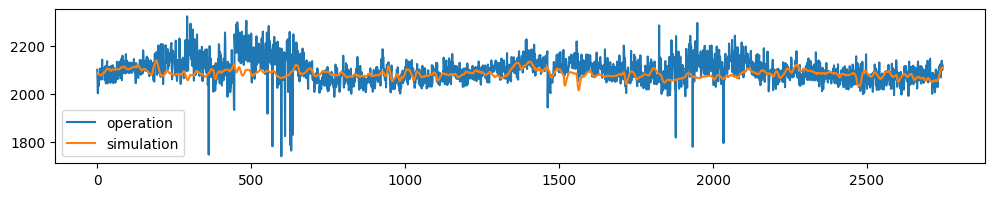

In [23]:
for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(generator.y_scaler.inverse_transform(generator.y_test)[:, i], label='operation')
    plt.plot(y_test[:, i], label='simulation')
    plt.legend()
    plt.show()


#### Evaluate

In [24]:
evaluator = Evaluator()

for i in range(output_size):
    metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test)[:, i], y_test[:, i])
    print(metrics_dict)

{'explained_variance_score': 0.03299961786496697, 'mean_absolute_error': 37.98942325736036, 'mean_squared_error': 2793.3959412640434, 'root_mean_squared_error': np.float64(52.85258689282903), 'median_absolute_error': 28.288151041670062, 'mean_absolute_percentage_error': 0.017992365880975938, 'd2_absolute_error_score': 0.0001729834847608025, 'd2_pinball_score': 0.0001729834847608025, 'r2_score': -0.04556176448624494}


In [25]:
evaluator = Evaluator()
metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test), y_test)
metrics_dict

{'explained_variance_score': 0.03299961786496697,
 'mean_absolute_error': 37.98942325736036,
 'mean_squared_error': 2793.3959412640434,
 'root_mean_squared_error': np.float64(52.85258689282903),
 'median_absolute_error': 28.288151041670062,
 'mean_absolute_percentage_error': 0.017992365880975938,
 'd2_absolute_error_score': 0.0001729834847608025,
 'd2_pinball_score': 0.0001729834847608025,
 'r2_score': -0.04556176448624494}

In [26]:
while True:
    time.sleep(1)
    pass

KeyboardInterrupt: 

### Coal-Fired Boiler

#### Data

In [46]:
df = pd.read_csv('./datasets/coal/data.csv', sep=",", decimal='.', parse_dates=["date"], infer_datetime_format=True).set_index('date').astype(float)
df.index = pd.to_datetime(df.index)
# df.index = pd.to_datetime(pd.date_range(start=df.index[0], periods=df.shape[0], freq="5min").strftime("%Y-%m-%d %H:%M:%S.%f"))
df = df.resample("1s").interpolate(method="linear", limit_direction="both", axis=0)
df.index.name = "date_time"
df.interpolate(method="linear", limit_direction="both", axis=0)
df.fillna(method='ffill', axis=0, inplace=True)

df = df.iloc[:100000, :]
print(df.shape)

/tmp/ipykernel_145763/2489098090.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv('./datasets/coal/data.csv', sep=",", decimal='.', parse_dates=["date"], infer_datetime_format=True).set_index('date').astype(float)


(100000, 30)


/tmp/ipykernel_145763/2489098090.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', axis=0, inplace=True)


In [47]:
# Z-score
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

df = df.resample("1s").interpolate(method="linear", limit_direction="both", axis=0)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100000 entries, 2022-03-27 14:28:54 to 2022-03-28 18:15:33
Freq: s
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   PT_8313A.AV_0#    100000 non-null  float64
 1   PT_8313B.AV_0#    100000 non-null  float64
 2   PT_8313C.AV_0#    100000 non-null  float64
 3   PT_8313D.AV_0#    100000 non-null  float64
 4   PT_8313E.AV_0#    100000 non-null  float64
 5   PT_8313F.AV_0#    100000 non-null  float64
 6   PTCA_8322A.AV_0#  100000 non-null  float64
 7   PTCA_8324.AV_0#   100000 non-null  float64
 8   TE_8319A.AV_0#    100000 non-null  float64
 9   TE_8319B.AV_0#    100000 non-null  float64
 10  TE_8313B.AV_0#    100000 non-null  float64
 11  TE_8303.AV_0#     100000 non-null  float64
 12  TE_8304.AV_0#     100000 non-null  float64
 13  TV_8329ZC.AV_0#   100000 non-null  float64
 14  FT_8301.AV_0#     100000 non-null  float64
 15  FT_8302.AV_0#     100000 n

In [49]:
df.head()

,PT_8313A.AV_0#,PT_8313B.AV_0#,PT_8313C.AV_0#,PT_8313D.AV_0#,PT_8313E.AV_0#,PT_8313F.AV_0#,PTCA_8322A.AV_0#,PTCA_8324.AV_0#,TE_8319A.AV_0#,TE_8319B.AV_0#,...,YFJ3_AI.AV_0#,YFJ3_ZD1.AV_0#,YFJ3_ZD2.AV_0#,SXLTCYZ.AV_0#,SXLTCYY.AV_0#,ZCLCCY.AV_0#,YCLCCY.AV_0#,YJJWSLL.AV_0#,ZZQBCHLL.AV_0#,TE_8332A.AV_0#
date_time,,,,,,,,,,,,,,,,,,,,,
2022-03-27 14:28:54,-142.280,-179.46,-150.68,-118.53,-142.62,-147.650,9.7,9.36,352.5,379.46,...,22.790,5.600,7.620,-129.15,-365.9,10667.39,10637.2,2.78,60.89,538.29
2022-03-27 14:28:55,-142.382,-180.97,-150.41,-114.20,-141.16,-148.976,9.7,9.36,352.5,379.46,...,22.788,5.512,7.678,-129.15,-365.9,10667.39,10637.2,2.78,60.89,538.29
2022-03-27 14:28:56,-142.484,-182.48,-150.14,-109.87,-139.70,-150.302,9.7,9.36,352.5,379.46,...,22.786,5.424,7.736,-129.15,-365.9,10667.39,10637.2,2.78,60.89,538.29
2022-03-27 14:28:57,-142.586,-183.99,-149.87,-105.54,-138.24,-151.628,9.7,9.36,352.5,379.46,...,22.784,5.336,7.794,-129.15,-365.9,10667.39,10637.2,2.78,60.89,538.29
2022-03-27 14:28:58,-142.688,-185.50,-149.60,-101.21,-136.78,-152.954,9.7,9.36,352.5,379.46,...,22.782,5.248,7.852,-129.15,-365.9,10667.39,10637.2,2.78,60.89,538.29


In [50]:
columns = [
    "PT_8313A.AV_0",
    "PT_8313B.AV_0",
    "PT_8313C.AV_0",
    "PT_8313D.AV_0",
    "PT_8313E.AV_0",
    "PT_8313F.AV_0",
    "PTCA_8322A.AV_0",
    "PTCA_8324.AV_0",
    "TE_8319A.AV_0",
    "TE_8319B.AV_0",
    "TE_8313B.AV_0",
    "TE_8303.AV_0",
    "TE_8304.AV_0",
    "TV_8329ZC.AV_0",
    "FT_8301.AV_0",
    "FT_8302.AV_0",
    "FT_8306A.AV_0",
    "AIR_8301A.AV_0",
    "FT_8306B.AV_0",
    "AIR_8301B.AV_0",
    "YFJ3_AI.AV_0",
    "YFJ3_ZD1.AV_0",
    "YFJ3_ZD2.AV_0",
    "SXLTCYZ.AV_0",
    "SXLTCYY.AV_0",
    "ZCLCCY.AV_0",
    "YCLCCY.AV_0",
    "YJJWSLL.AV_0",
    "ZZQBCHLL.AV_0",
    "TE_8332A.AV_0",
]

columns = [
    "Upper furnace pressure (A)",
    "Upper furnace pressure (B)",
    "Upper furnace pressure (C)",
    "Upper furnace pressure (D)",
    "Upper furnace pressure (E)",
    "Upper furnace pressure (F)",
    "Pot pressure (left)",
    "Container outlet vapour pressure",
    "Flue gas temperature at the upper economizer outlet (left)",
    "Flue gas temperature at the upper economizer outlet (right)",
    "Temperature in the upper part of the furnace chamber (right)",
    "Primary air preheater outlet air temperature",
    "Secondary air preheater outlet air temperature",
    "Primary desuperheater outlet steam temperature regulating valve",
    "Primary fan outlet flow rate",
    "Secondary fan outlet flow",
    "Return air chamber air flow (left)",
    "Upper economiser inlet flue gas oxygen (left)",
    "Return air chamber air flow (right)",
    "Upper economiser inlet flue gas oxygen (right)",
    "Induced draft fan motor current",
    "Vibration of induced draft fan bearing shell (A)",
    "Vibration of induced draft fan bearing shell (B)",
    "Differential pressure between upper and lower hearth (left)",
    "Differential pressure between upper and lower hearth (right)",
    "Differential pressure in the left layer",
    "Differential pressure in the right layer",
    "Primary desuperheating water flow output",
    "Main steam flow rate after compensation",
    "Boiler outlet steam temperature",
]

input_columns = [
    "Pot pressure (left)",
    "Flue gas temperature at the upper economizer outlet (left)",
    "Flue gas temperature at the upper economizer outlet (right)",
    "Temperature in the upper part of the furnace chamber (right)",
    "Primary air preheater outlet air temperature",
    "Primary desuperheater outlet steam temperature regulating valve",
    "Secondary fan outlet flow",
    "Induced draft fan motor current",
    "Vibration of induced draft fan bearing shell (A)",
]

output_columns = [
    "Container outlet vapour pressure",
    "Primary desuperheating water flow output",
    "Main steam flow rate after compensation",
    "Boiler outlet steam temperature",
]

df.index.names = ["date_time"]
df.columns = columns

<Axes: >

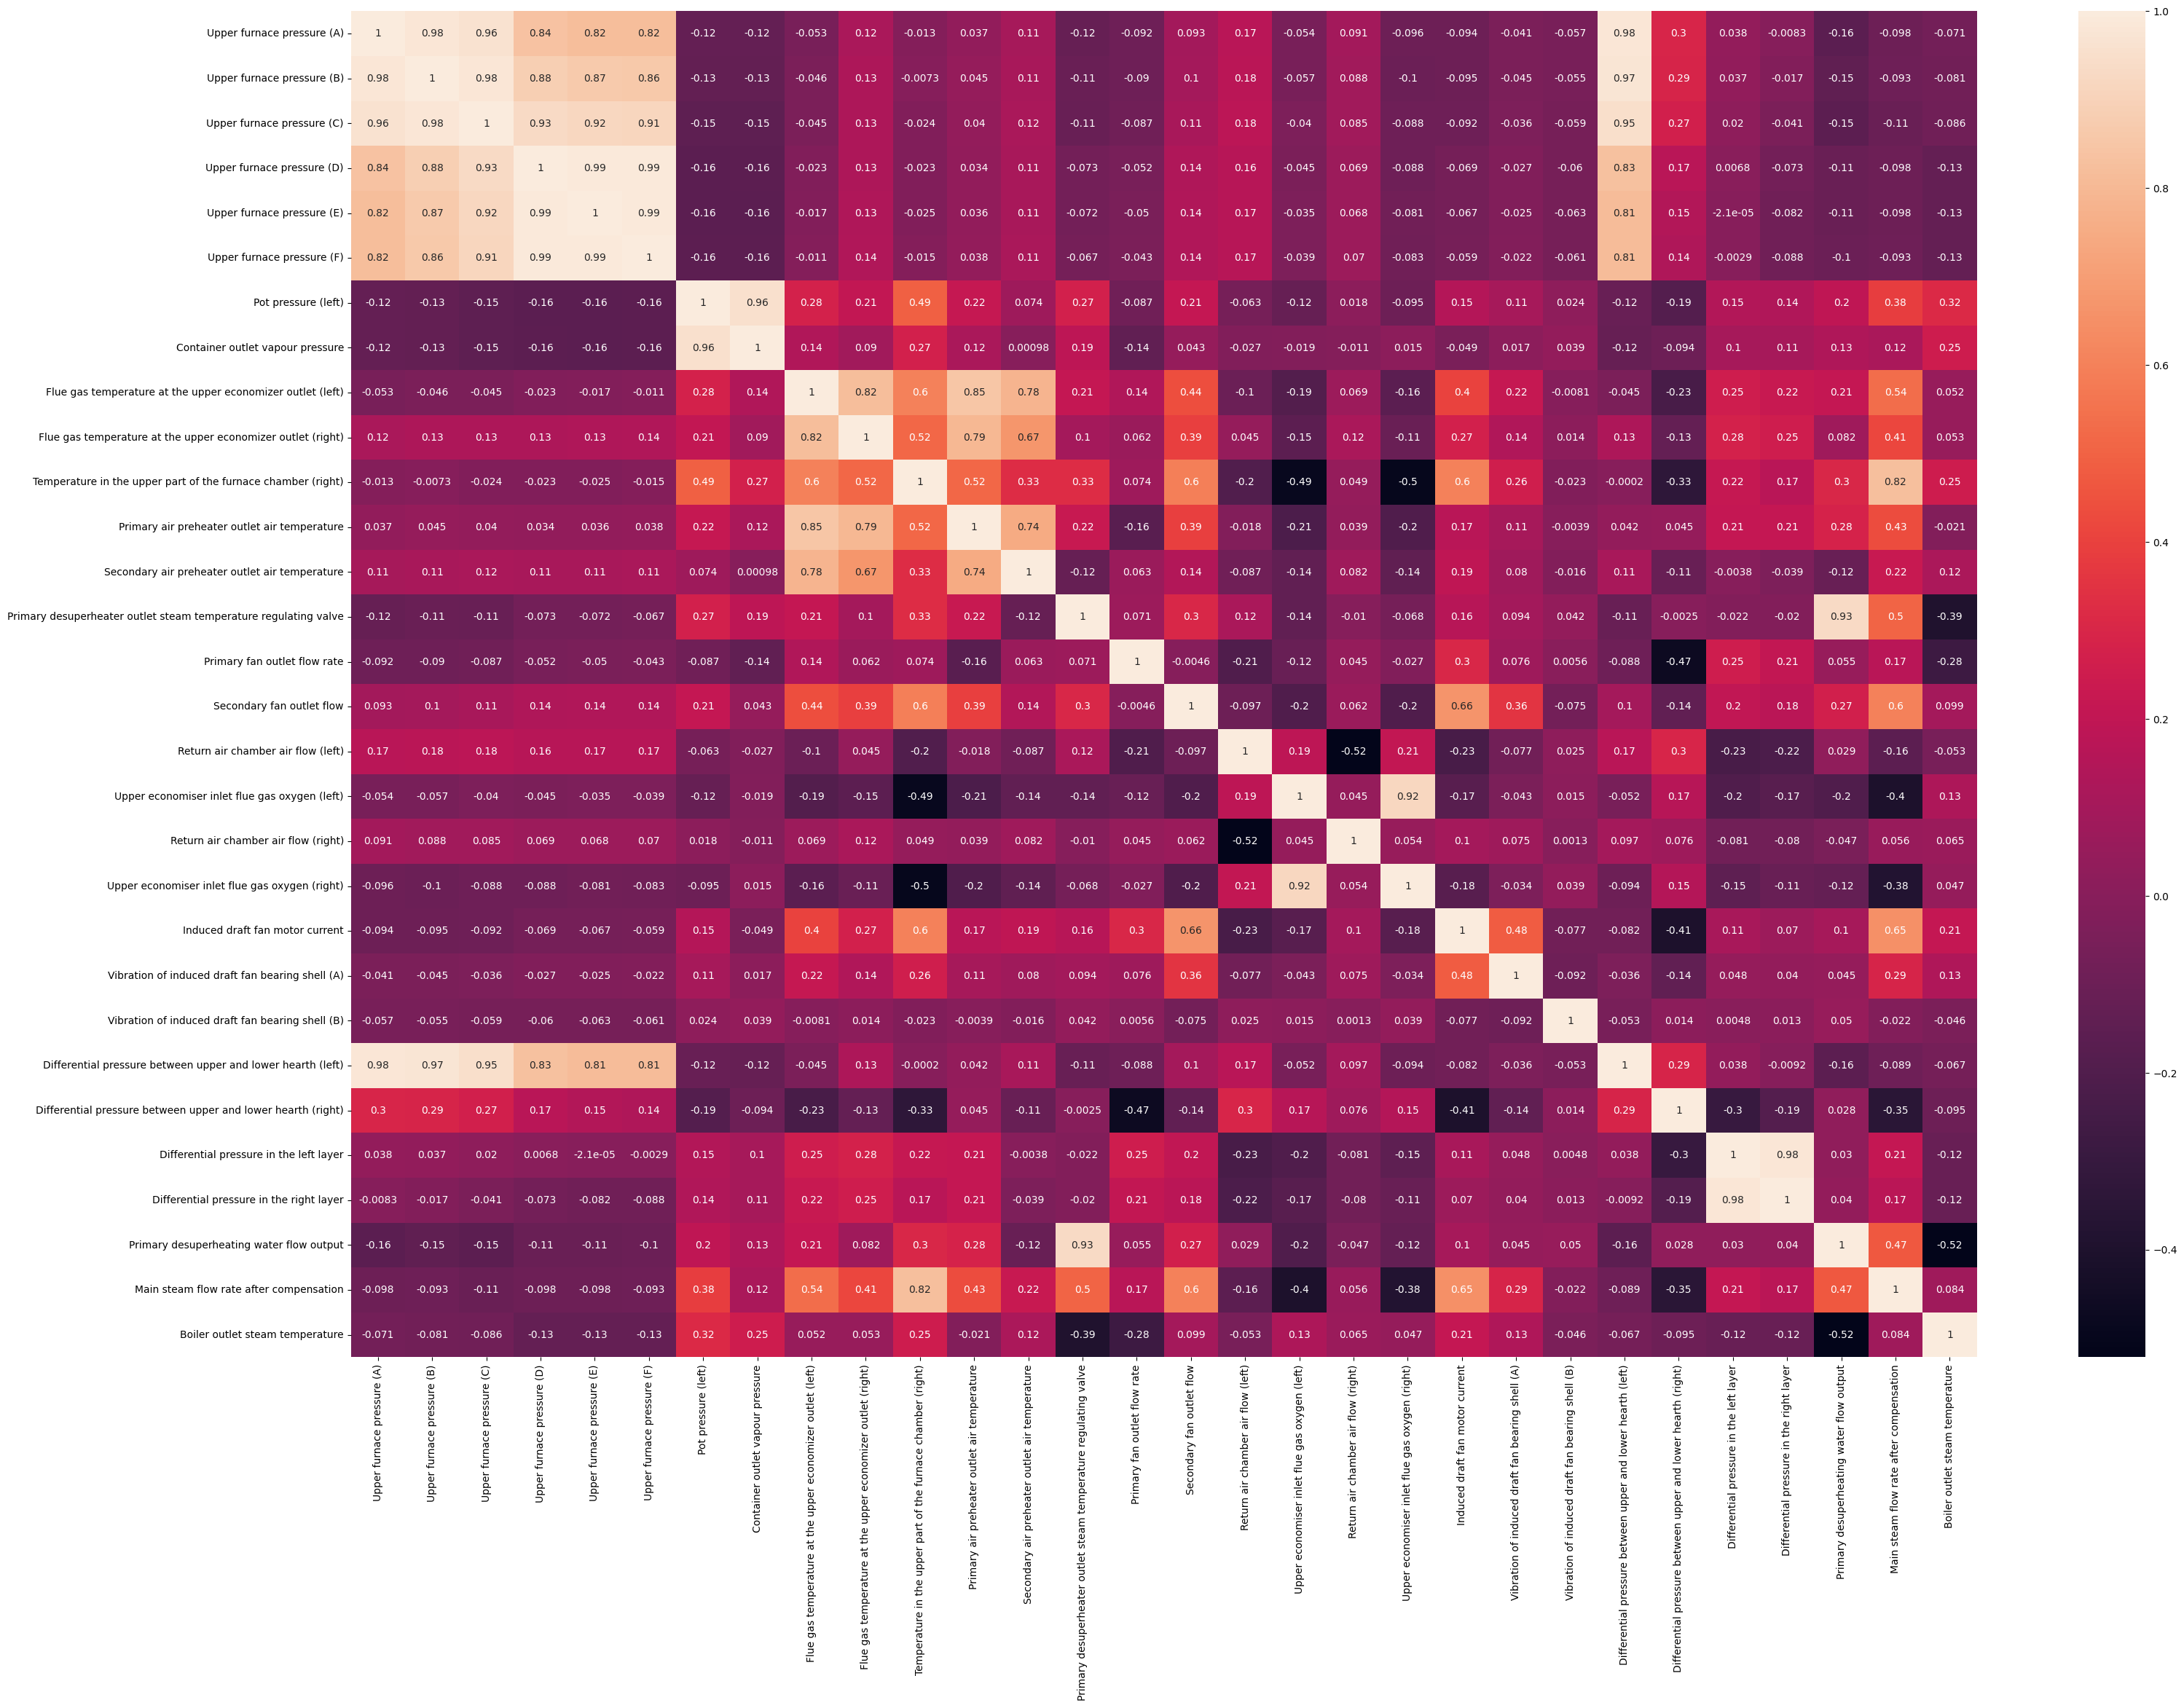

In [51]:
df_corr = df.corr(method="pearson")

plt.figure(figsize=(36, 24))
sns.heatmap(df_corr, annot=True)

In [52]:
input_size = len(input_columns)
output_size = len(output_columns)

x = df[input_columns].values
y = df[output_columns].values

In [53]:
df[input_columns + output_columns].describe()

,Pot pressure (left),Flue gas temperature at the upper economizer outlet (left),Flue gas temperature at the upper economizer outlet (right),Temperature in the upper part of the furnace chamber (right),Primary air preheater outlet air temperature,Primary desuperheater outlet steam temperature regulating valve,Secondary fan outlet flow,Induced draft fan motor current,Vibration of induced draft fan bearing shell (A),Container outlet vapour pressure,Primary desuperheating water flow output,Main steam flow rate after compensation,Boiler outlet steam temperature
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,9.763849,350.008869,382.607630,770.907754,206.748661,15.822187,18929.866056,22.380298,5.518147,9.443088,2.723705,59.219792,537.306707
std,0.057278,2.979687,6.358156,8.063912,3.371604,3.946199,1442.006675,0.582742,0.416707,0.054855,0.259308,1.652612,4.319834
min,9.622000,342.530000,368.390000,750.800000,199.754000,6.788000,15001.720000,20.706000,4.374000,9.306000,2.116000,54.758000,526.294000
25%,9.730000,348.173490,377.620000,766.051750,204.320000,14.010000,17973.650783,21.936000,5.227800,9.410000,2.582000,58.140000,534.428000
50%,9.764286,350.088437,383.340000,770.850000,206.692813,16.070000,18905.971000,22.370000,5.490000,9.448000,2.700000,59.132000,537.678000
75%,9.803321,352.160000,387.483838,775.636500,209.166000,18.620000,19882.228500,22.668000,5.782000,9.480000,2.890000,60.330000,540.200000
max,9.910000,357.930000,400.274000,791.630000,216.504000,26.010000,22934.486000,24.000000,6.714000,9.584000,3.354000,63.752000,547.010000


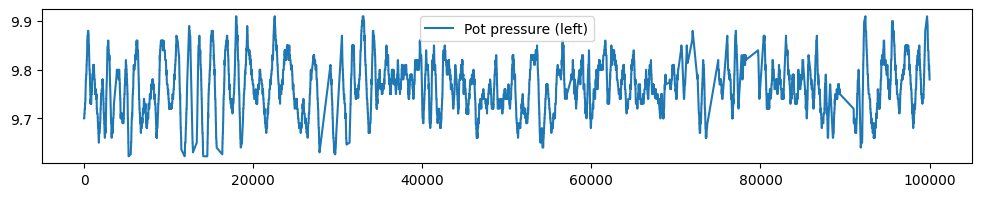

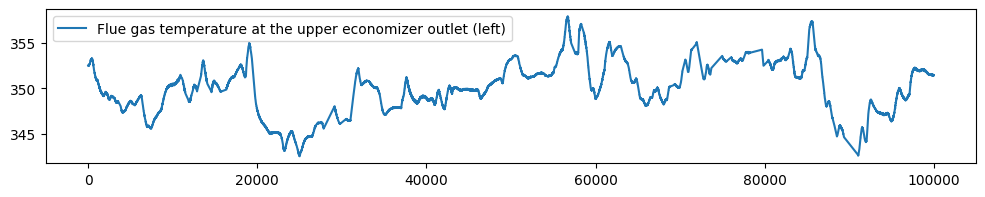

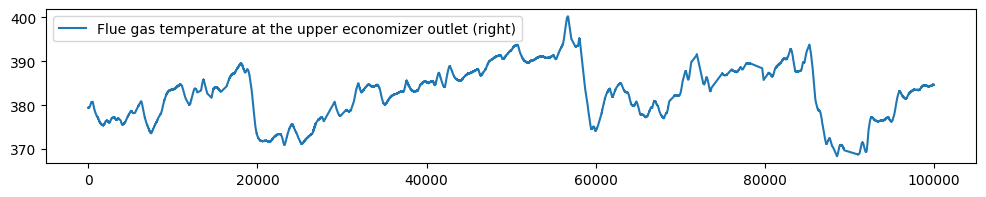

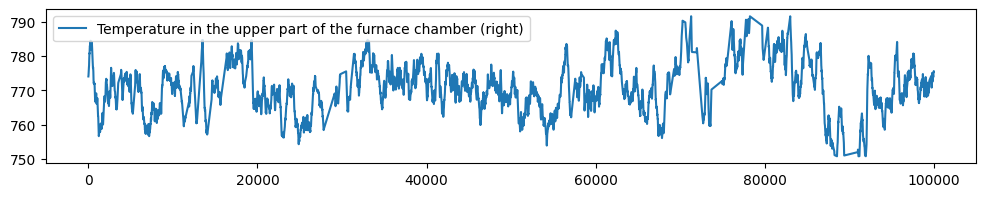

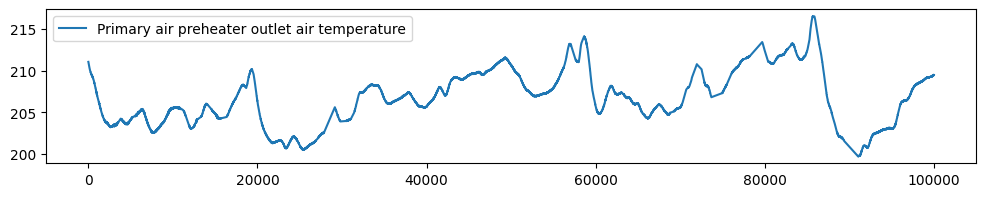

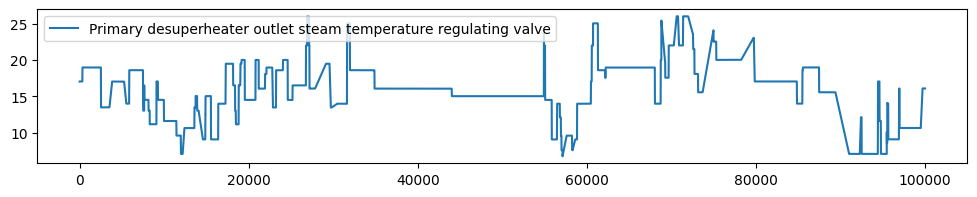

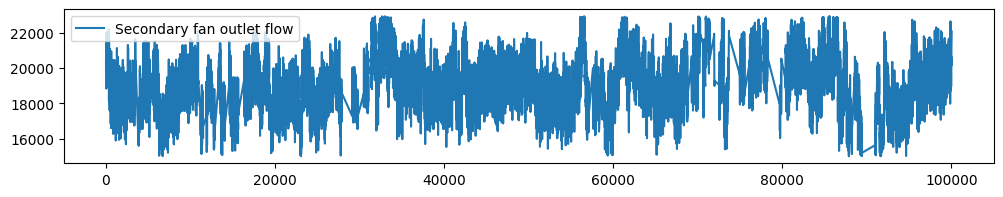

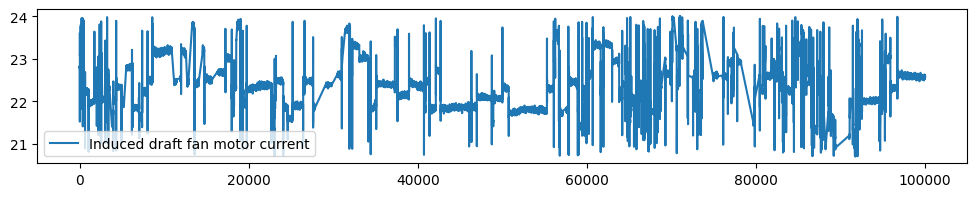

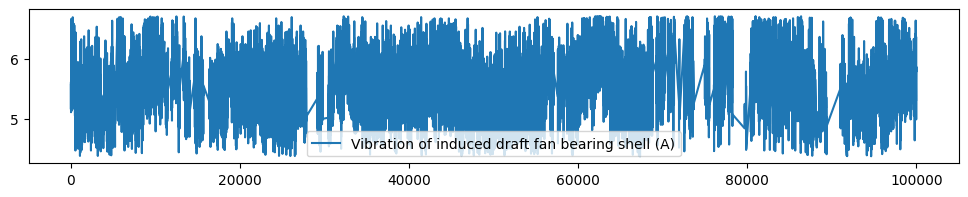

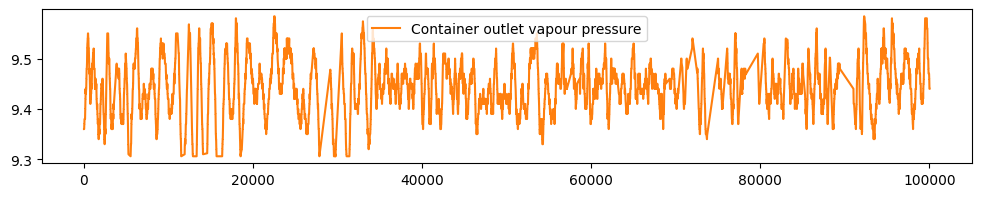

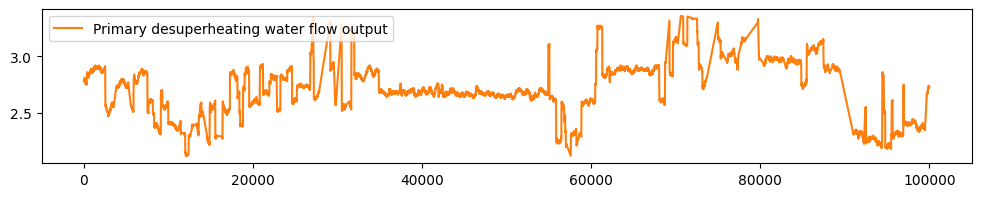

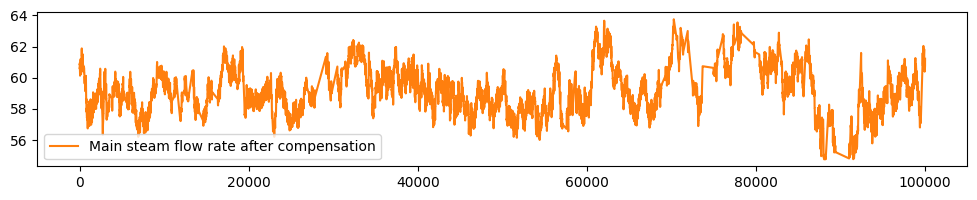

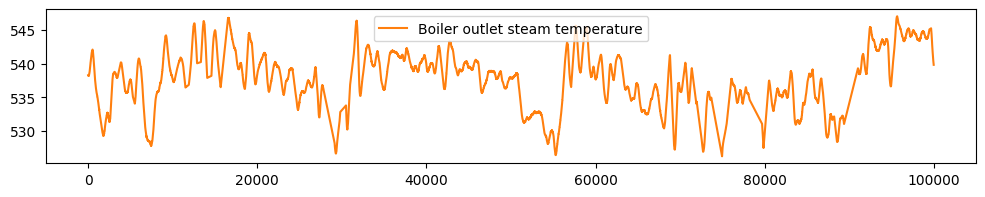

In [54]:
for i in range(x.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(x[:, i], label=input_columns[i])
    plt.legend()
    plt.show()

for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(y[:, i], label=output_columns[i], color="tab:orange")
    plt.legend()
    plt.show()

In [55]:
batch_size = 2**7
lag = 2**5

generator = Generator()
train_dataloader, val_dataloader = generator.generate_dataloaders(x, y, lag, batch_size)

#### Model

In [67]:
config = {
    "input_size": input_size + output_size,
    "output_size": output_size,
    "hidden_size": 2**5,
    "num_layers": 2**3,
    "learning_rate": 1e-3,
    "dropout": 0,
    "lag": lag,
    "epochs": 2**5
}

In [68]:
repeater = Repeater(**config).to(device)
print(repeater)

Repeater(
  (lstm): LSTM(13, 32, num_layers=8, batch_first=True)
  (linear): Linear(in_features=32, out_features=4, bias=True)
  (loss_fn): MSELoss()
)


#### Train

In [69]:
%%time
repeater.fit(train_dataloader, val_dataloader)

Epoch 1/32
391/391 [====================================================================================================] 100%
0.0520s 0.0520s/step - train_loss: 0.05726269 - val_loss: 0.08490867 

Epoch 2/32
391/391 [====================================================================================================] 100%
0.1052s 0.0526s/step - train_loss: 0.03637638 - val_loss: 0.06058341 

Epoch 3/32
391/391 [====================================================================================================] 100%
0.1513s 0.0504s/step - train_loss: 0.02648689 - val_loss: 0.04811501 

Epoch 4/32
391/391 [====================================================================================================] 100%
0.1984s 0.0496s/step - train_loss: 0.02055528 - val_loss: 0.04068549 

Epoch 5/32
391/391 [====================================================================================================] 100%
0.2463s 0.0493s/step - train_loss: 0.01673821 - val_loss: 0.03560290 

Epoch 6/32

In [70]:
repeater.x_min_ = generator.x_scaler.min_.tolist()
repeater.x_scale_ = generator.x_scaler.scale_.tolist()
repeater.x_data_min_ = generator.x_scaler.data_min_.tolist()
repeater.x_data_max_ = generator.x_scaler.data_max_.tolist()
repeater.x_data_range_ = generator.x_scaler.data_range_.tolist()
repeater.x_n_features_in_ = generator.x_scaler.n_features_in_
repeater.x_n_samples_seen_ = generator.x_scaler.n_samples_seen_

repeater.y_min_ = generator.y_scaler.min_.tolist()
repeater.y_scale_ = generator.y_scaler.scale_.tolist()
repeater.y_data_min_ = generator.y_scaler.data_min_.tolist()
repeater.y_data_max_ = generator.y_scaler.data_max_.tolist()
repeater.y_data_range_ = generator.y_scaler.data_range_.tolist()
repeater.y_n_features_in_ = generator.y_scaler.n_features_in_
repeater.y_n_samples_seen_ = generator.y_scaler.n_samples_seen_

model_path = "./models/{}.pt".format(uuid.uuid4())
torch.jit.script(repeater).save(model_path)

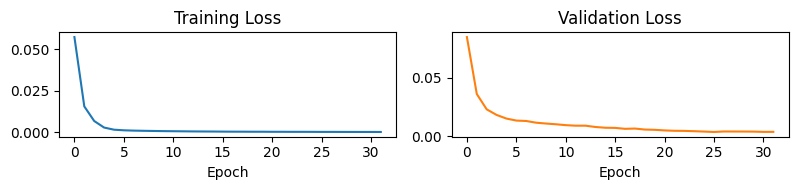

In [71]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2))
axs[0].plot(repeater.train_loss)
axs[0].set_title('Training Loss')
axs[1].plot(repeater.val_loss, color='tab:orange')
axs[1].set_title('Validation Loss')

for ax in axs.flat:
    ax.set(xlabel='Epoch', ylabel='')

fig.tight_layout()

#### Test

In [72]:
for parameter in repeater.parameters():
  parameter.requires_grad = False
repeater.eval()

Repeater(
  (lstm): LSTM(13, 32, num_layers=8, batch_first=True)
  (linear): Linear(in_features=32, out_features=4, bias=True)
  (loss_fn): MSELoss()
)

In [73]:
y_test_scaled = repeater.test(generator.x_test, (generator.x_val, generator.y_val))
y_test = generator.y_scaler.inverse_transform(y_test_scaled)

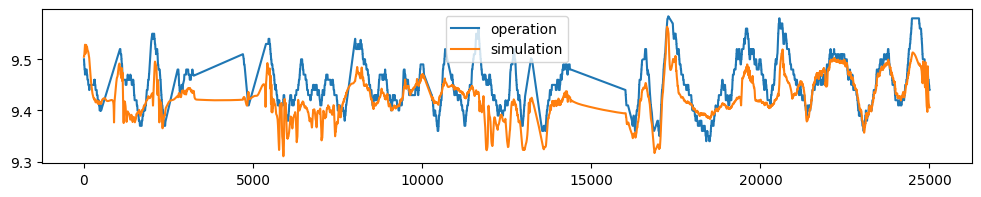

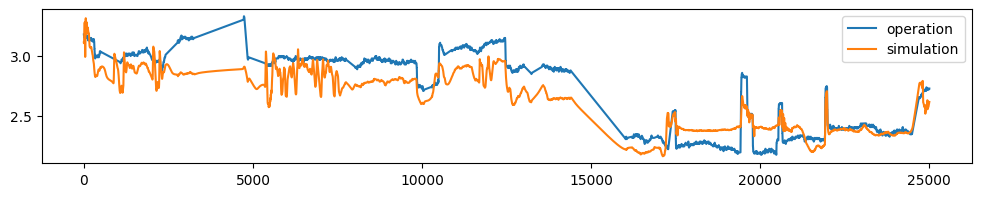

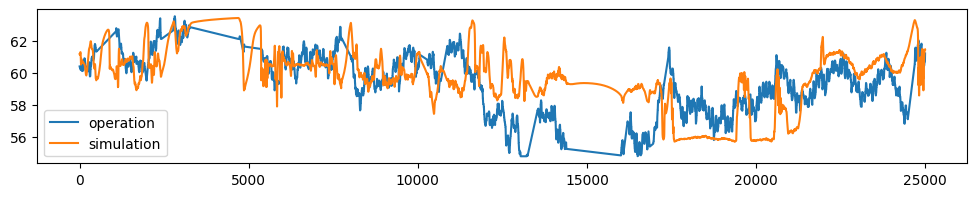

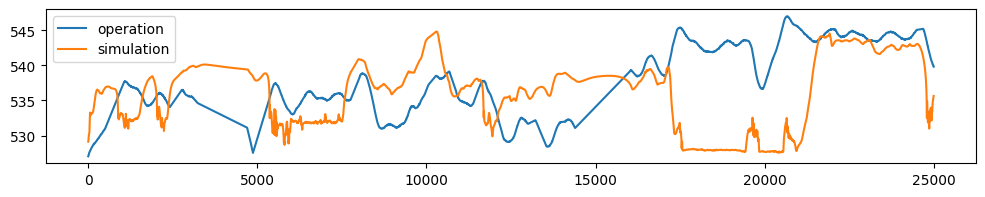

In [74]:
for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(generator.y_scaler.inverse_transform(generator.y_test)[:, i], label='operation')
    plt.plot(y_test[:, i], label='simulation')
    plt.legend()
    plt.show()


#### Evaluate

In [75]:
evaluator = Evaluator()

for i in range(output_size):
    metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test)[:, i], y_test[:, i])
    print(metrics_dict)

{'explained_variance_score': 0.4630479068555844, 'mean_absolute_error': 0.03947356877754344, 'mean_squared_error': 0.0022753062748279403, 'root_mean_squared_error': np.float64(0.04770017059537566), 'median_absolute_error': 0.037157937225451576, 'mean_absolute_percentage_error': 0.004167470380766843, 'd2_absolute_error_score': -0.06707885382653567, 'd2_pinball_score': -0.06707885382653567, 'r2_score': -0.054078280623582886}
{'explained_variance_score': 0.8218205653768405, 'mean_absolute_error': 0.153002308205913, 'mean_squared_error': 0.03163666430653578, 'root_mean_squared_error': np.float64(0.17786698486941238), 'median_absolute_error': 0.15094238330471876, 'mean_absolute_percentage_error': 0.05441057726204887, 'd2_absolute_error_score': 0.46450789006227877, 'd2_pinball_score': 0.46450789006227877, 'r2_score': 0.7139554931706015}
{'explained_variance_score': 0.1686096629822722, 'mean_absolute_error': 1.7126219117124026, 'mean_squared_error': 4.5379611652133836, 'root_mean_squared_erro

In [76]:
evaluator = Evaluator()
metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test), y_test)
metrics_dict

{'explained_variance_score': 0.11020575327346405,
 'mean_absolute_error': 1.8548221508383276,
 'mean_squared_error': 13.753924623302822,
 'root_mean_squared_error': np.float64(3.708628401889683),
 'median_absolute_error': 1.4798044800043733,
 'mean_absolute_percentage_error': 0.024575801556424963,
 'd2_absolute_error_score': 0.04018679545245005,
 'd2_pinball_score': 0.04018679545245005,
 'r2_score': -0.06813732952307427}

In [77]:
while True:
    time.sleep(1)
    pass

KeyboardInterrupt: 